#Etape 1 - Importation des librairies et chargement des fichiers

#1.1 - Importation des librairies

In [290]:
#Importation de la librairie Pandas
import pandas as pd

#1.2 - Chargement des fichiers Excel

In [291]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

In [292]:
#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

In [293]:
#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

In [294]:
#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')

#Etape 2 - Analyse exploratoire du fichier population

#2.1 Analyse exploratoire du fichier Population

# 2.1.1 - Afficher les dimensions du dataset

In [295]:
print("Les dimensions du Dataset sont :\n")
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Les dimensions du Dataset sont :

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


#2.1.2 - Consulter le nombre de colonnes

In [296]:
#Consulter le nombre de colonnes
#print (population.info())
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 3 colonne(s)


#2.1.3 - Afficher la nature des données de chaque colonne

In [297]:
#La nature des données dans chacune des colonnes
for col in population.columns:
    print(f"La nature des données de la colonne {col}: {population[col].dtype}")

La nature des données de la colonne Zone: object
La nature des données de la colonne Année: int64
La nature des données de la colonne Valeur: float64


#2.1.4 - Afficher le nombre de valeurs présentes dans chacune des colonnes

In [298]:
#Le nombre de valeurs présentes dans chacune des colonnes
for col in population.columns:
    print(f"Le nombre des valeurs présentes de la colonne {col}: {population[col].notnull().sum()}")

Le nombre des valeurs présentes de la colonne Zone: 1416
Le nombre des valeurs présentes de la colonne Année: 1416
Le nombre des valeurs présentes de la colonne Valeur: 1416


In [299]:
#Affichage les 5 premières lignes de la table
print (population.head())

          Zone  Année     Valeur
0  Afghanistan   2013  32269.589
1  Afghanistan   2014  33370.794
2  Afghanistan   2015  34413.603
3  Afghanistan   2016  35383.032
4  Afghanistan   2017  36296.113


In [300]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000

#Multiplication de la colonne valeur par 1000
population['Valeur'] *= 1000
population['Valeur']

,Valeur
0,32269589.0
1,33370794.0
2,34413603.0
3,35383032.0
4,36296113.0
...,...
1411,13586707.0
1412,13814629.0
1413,14030331.0
1414,14236595.0


In [301]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur':'population'}, inplace=True)


In [302]:
#Affichage les 5 premières lignes de la table pour voir les modifications
print(population.head())

          Zone  Année  population
0  Afghanistan   2013  32269589.0
1  Afghanistan   2014  33370794.0
2  Afghanistan   2015  34413603.0
3  Afghanistan   2016  35383032.0
4  Afghanistan   2017  36296113.0


#2.2 - Analyse exploratoire du fichier disponibilité alimentaire

In [303]:
#Afficher les dimensions du dataset
dimensions = dispo_alimentaire.shape
#print (dispo_alimentaire.shape)
print(f"Les dimensions du dataset sont (Nombre de lignes : {dimensions[0]},Nombre de colonnes :{dimensions[1]}")
#print(dispo_alimentaire.info())
#print(dispo_alimentaire.describe())

Les dimensions du dataset sont (Nombre de lignes : 15605,Nombre de colonnes :18


In [304]:
#Consulter le nombre de colonnes
print(f"Le Dataset comporte : {dispo_alimentaire.shape[1]} colonne(s)")

Le Dataset comporte : 18 colonne(s)


In [305]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [306]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0,inplace = True)


In [307]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alimentaire.head()

# Indices des  11 colonnes à parcourir
Liste_a_parcourir = ['Aliments pour animaux',
                     'Autres Utilisations',
                     'Disponibilité intérieure',
                     'Exportations - Quantité',
                     'Importations - Quantité',
                     'Nourriture',
                     'Pertes',
                     'Production',
                     'Semences',
                     'Traitement',
                     'Variation de stock']

dispo_alimentaire['Aliments pour animaux'] *= 1000000
dispo_alimentaire['Autres Utilisations'] *= 1000000
dispo_alimentaire['Disponibilité intérieure'] *= 1000000
dispo_alimentaire['Exportations - Quantité'] *= 1000000
dispo_alimentaire['Importations - Quantité'] *= 1000000
dispo_alimentaire['Nourriture'] *= 1000000
dispo_alimentaire['Pertes'] *= 1000000
dispo_alimentaire['Production'] *= 1000000
dispo_alimentaire['Semences'] *= 1000000
dispo_alimentaire['Traitement'] *= 1000000
dispo_alimentaire['Variation de stock'] *= 1000000


In [308]:
#Affichage les 5 premières lignes de la table
print(dispo_alimentaire.head())

          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    0.0   
1  Afghanistan        Agrumes, Autres  vegetale                    0.0   
2  Afghanistan  Aliments pour enfants  vegetale                    0.0   
3  Afghanistan                 Ananas  vegetale                    0.0   
4  Afghanistan                Bananes  vegetale                    0.0   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  0.0                                             5.0   
1                  0.0                                             1.0   
2                  0.0                                             1.0   
3                  0.0                                             0.0   
4                  0.0                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)  \
0                                               1

#2.3 - Analyse exploratoire du fichier aide alimentaire

In [309]:
#afficher les dimensions du dataset
print("Les dimensions du Dataset sont :\n")
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))
#print (df.info())

Les dimensions du Dataset sont :

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [310]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 4 colonne(s)


In [311]:
#affichage des 5 premières lignes de la table
print(aide_alimentaire.head())

  Pays bénéficiaire  Année              Produit  Valeur
0       Afghanistan   2013  Autres non-céréales     682
1       Afghanistan   2014  Autres non-céréales     335
2       Afghanistan   2013         Blé et Farin   39224
3       Afghanistan   2014         Blé et Farin   15160
4       Afghanistan   2013             Céréales   40504


In [312]:
#changement du nom de la colonne Pays bénéficiaire par zone
aide_alimentaire.rename(columns={'Pays bénéficiaire':'zone'}, inplace=True)
aide_alimentaire.head()

,zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [313]:
#multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] = aide_alimentaire['Valeur'] * 1000


In [314]:
#affichage des 5 premières lignes de la table
aide_alimentaire.head()

,zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


#2.4 - Analyse exploratoire du fichier sous-nutrition

In [315]:
#afficher les dimensions du dataset
print("Les dimensions du Dataset sont :\n")
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))
#print (df.info())

Les dimensions du Dataset sont :

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [316]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))


Le tableau comporte 3 colonne(s)


In [317]:
#affichage des 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [318]:
#changement du nom de la colonne Valeur par sous-nutrition
sous_nutrition.rename(columns={'Valeur':'sous-nutrition'}, inplace=True)


In [319]:
# Conversion de la colonne en numérique, avec gestion des erreurs
sous_nutrition['sous-nutrition'] = pd.to_numeric(sous_nutrition['sous-nutrition'], errors='coerce')


In [320]:
#Multiplication de la colonne sous_nutrition par 1000000
if sous_nutrition is not None and "sous-nutrition" in sous_nutrition.columns:
    sous_nutrition["sous-nutrition"] = sous_nutrition["sous-nutrition"] * 1000000
    sous_nutrition["sous-nutrition"] = sous_nutrition["sous-nutrition"].fillna(0)
else:
    print("Le DataFrame est vide ou ne contient pas la colonne 'sous-nutrition'.")

In [321]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,sous-nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


#Etape 3 : Analyse des données

#3.1 Proportion de personnes en sous nutrition

In [322]:
#il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
# Supposons que vous avez déjà vos DataFrames: population et sous_nutrition
# Imprimer le DataFrame d'origine
print("DataFrame population avant le filtrage:")
print(population)
print("Colonnes de population:")
print(population.columns)

# Vérification de la structure de vos DataFrames
print("\nColonnes de sous_nutrition:")
print(sous_nutrition.columns)
print("DataFrame sous-nutrition avant le filtrage:")
print(sous_nutrition)

# Vérification du DataFrame initial
print(population.head())  # Montre le début du DataFrame


# Filtrer la population pour l'année 2017
df_population_2017 = population.loc[population['Année'] == 2017]
print(f"\n après filtrage Population 2017:{df_population_2017}")

# Assurez-vous que 'Année' est de type numérique
sous_nutrition['Année'] = sous_nutrition['Année'].astype(str)
print(f"{type(sous_nutrition['Année'])}")

# Extraire l'année de début pour chaque ligne
sous_nutrition['Année'] = sous_nutrition['Année'].str.split('-').str[0].astype(int)  # Prend la première année

# Ensuite, filtrez comme précédemment
df_sous_nutrition_2017 = sous_nutrition.loc[(sous_nutrition['Année'] > 2016) & (sous_nutrition['Année'] < 2018)]
print("\nSous-nutrition 2017 après filtrage:")

# Faire la jointure sur  'Zone'
df_jointure_2017 = pd.merge(
    df_population_2017,
    df_sous_nutrition_2017,
    left_on='Zone',
    right_on='Zone',
    how='inner'
    )

# Afficher les résultats triés par sous-nutrition
print("\nJointure 2017 triée par sous-nutrition:")
print(df_sous_nutrition_2017.sort_values(by='sous-nutrition', ascending=False))



DataFrame population avant le filtrage:
             Zone  Année  population
0     Afghanistan   2013  32269589.0
1     Afghanistan   2014  33370794.0
2     Afghanistan   2015  34413603.0
3     Afghanistan   2016  35383032.0
4     Afghanistan   2017  36296113.0
...           ...    ...         ...
1411     Zimbabwe   2014  13586707.0
1412     Zimbabwe   2015  13814629.0
1413     Zimbabwe   2016  14030331.0
1414     Zimbabwe   2017  14236595.0
1415     Zimbabwe   2018  14438802.0

[1416 rows x 3 columns]
Colonnes de population:
Index(['Zone', 'Année', 'population'], dtype='object')

Colonnes de sous_nutrition:
Index(['Zone', 'Année', 'sous-nutrition'], dtype='object')
DataFrame sous-nutrition avant le filtrage:
             Zone      Année  sous-nutrition
0     Afghanistan  2012-2014       8600000.0
1     Afghanistan  2013-2015       8800000.0
2     Afghanistan  2014-2016       8900000.0
3     Afghanistan  2015-2017       9700000.0
4     Afghanistan  2016-2018      10500000.0
...       

In [323]:
#affichage du dataset
print(df_jointure_2017.head(10))

                 Zone  Année_x  population  Année_y  sous-nutrition
0         Afghanistan     2017  36296113.0     2017      11100000.0
1      Afrique du Sud     2017  57009756.0     2017       3300000.0
2             Albanie     2017   2884169.0     2017        100000.0
3             Algérie     2017  41389189.0     2017       1200000.0
4           Allemagne     2017  82658409.0     2017             0.0
5             Andorre     2017     77001.0     2017             0.0
6              Angola     2017  29816766.0     2017       5700000.0
7  Antigua-et-Barbuda     2017     95426.0     2017             0.0
8     Arabie saoudite     2017  33101179.0     2017       1600000.0
9           Argentine     2017  43937140.0     2017       1700000.0


In [324]:
#calcul et affichage du nombre de personnes en état de sous nutrition

#il faut d'abord remplacer les Nan par des 0
df_jointure_2017.fillna(0,inplace=True)

Nbsousnutrition = df_jointure_2017['sous-nutrition'].sum()
Nbpopulation = df_jointure_2017['population'].sum()
CalculSousNutrition =  round(Nbsousnutrition / Nbpopulation * 100,2)

# Fonction pour formater les nombres
def format_americain(x):
    return f"{x:,.2f}"  # Format américain avec 2 décimales

print(f'Affichage du nombre de personnes en état de sous-nutrition :  {format_americain(Nbsousnutrition)}')
print(f'sur une population 2017 de :  {format_americain(Nbpopulation)}')
print(f'soit , en proportion :  {CalculSousNutrition}%')

Affichage du nombre de personnes en état de sous-nutrition :  544,200,000.00
sur une population 2017 de :  7,543,798,779.00
soit , en proportion :  7.21%


# Quels continents contribuent à ces 536 millions, et dans quelles proportions ?

In [325]:
#Table pays → continent (extrait minimal)
continent_map = {
    'Afghanistan': 'Asie',
    'Afrique du Sud': 'Afrique',
    'Albanie': 'Europe',
    'Algérie': 'Afrique',
    'Allemagne': 'Europe',
    'Andorre': 'Europe',
    'Angola': 'Afrique',
    'Antigua-et-Barbuda': 'Amérique',
    'Arabie saoudite': 'Asie',
    'Argentine': 'Amérique',
    'Arménie': 'Europe',
    'Australie': 'Océanie',
    'Autriche': 'Europe',
    'Azerbaïdjan': 'Asie',
    'Bahamas': 'Amérique',
    'Bahreïn': 'Asie',
    'Bangladesh': 'Asie',
    'Barbade': 'Amérique',
    'Bélarus': 'Europe',
    'Belgique': 'Europe',
    'Belize': 'Amérique',
    'Bénin': 'Afrique',
    'Bermudes': 'Amérique',
    'Bhoutan': 'Asie',
    'Bolivie (État plurinational de)': 'Amérique',
    'Bosnie-Herzégovine': 'Europe',
    'Botswana': 'Afrique',
    'Brésil': 'Amérique',
    'Brunéi Darussalam': 'Asie',
    'Bulgarie': 'Europe',
    'Burkina Faso': 'Afrique',
    'Burundi': 'Afrique',
    'Cabo Verde': 'Afrique',
    'Cambodge': 'Asie',
    'Cameroun': 'Afrique',
    'Canada': 'Amérique',
    'Chili': 'Amérique',
    'Chine - RAS de Hong-Kong': 'Asie',
    'Chine - RAS de Macao': 'Asie',
    'Chine, continentale': 'Asie',
    'Chine, Taiwan Province de': 'Asie',
    'Chypre': 'Europe',
    'Colombie': 'Amérique',
    'Comores': 'Afrique',
    'Congo': 'Afrique',
    'Costa Rica': 'Amérique',
    "Côte d'Ivoire": 'Afrique',
    'Croatie': 'Europe',
    'Cuba': 'Amérique',
    'Danemark': 'Europe',
    'Djibouti': 'Afrique',
    'Dominique': 'Amérique',
    'Égypte': 'Afrique',
    'El Salvador': 'Amérique',
    'Émirats arabes unis': 'Asie',
    'Équateur': 'Amérique',
    'Érythrée': 'Afrique',
    'Espagne': 'Europe',
    'Estonie': 'Europe',
    'Eswatini': 'Afrique',
    "États-Unis d'Amérique": 'Amérique',
    'Éthiopie': 'Afrique',
    'Fédération de Russie': 'Europe',
    'Fidji': 'Océanie',
    'Finlande': 'Europe',
    'France': 'Europe',
    'Gabon': 'Afrique',
    'Gambie': 'Afrique',
    'Géorgie': 'Europe',
    'Ghana': 'Afrique',
    'Grèce': 'Europe',
    'Grenade': 'Amérique',
    'Groenland': 'Amérique',
    'Guatemala': 'Amérique',
    'Guinée': 'Afrique',
    'Guinée équatoriale': 'Afrique',
    'Guinée-Bissau': 'Afrique',
    'Guyana': 'Amérique',
    'Haïti': 'Amérique',
    'Honduras': 'Amérique',
    'Hongrie': 'Europe',
    'Îles Cook': 'Océanie',
    'Îles Marshall': 'Océanie',
    'Îles Salomon': 'Océanie',
    'Inde': 'Asie',
    'Indonésie': 'Asie',
    "Iran (République islamique d')": 'Asie',
    'Iraq': 'Asie',
    'Irlande': 'Europe',
    'Islande': 'Europe',
    'Israël': 'Asie',
    'Italie': 'Europe',
    'Jamaïque': 'Amérique',
    'Japon': 'Asie',
    'Jordanie': 'Asie',
    'Kazakhstan': 'Asie',
    'Kenya': 'Afrique',
    'Kirghizistan': 'Asie',
    'Kiribati': 'Océanie',
    'Koweït': 'Asie',
    'Lesotho': 'Afrique',
    'Lettonie': 'Europe',
    'Liban': 'Asie',
    'Libéria': 'Afrique',
    'Libye': 'Afrique',
    'Lituanie': 'Europe',
    'Luxembourg': 'Europe',
    'Macédoine du Nord': 'Europe',
    'Madagascar': 'Afrique',
    'Malaisie': 'Asie',
    'Malawi': 'Afrique',
    'Maldives': 'Asie',
    'Mali': 'Afrique',
    'Malte': 'Europe',
    'Maroc': 'Afrique',
    'Maurice': 'Afrique',
    'Mauritanie': 'Afrique',
    'Mexique': 'Amérique',
    'Micronésie (États fédérés de)': 'Océanie',
    'Mongolie': 'Asie',
    'Monténégro': 'Europe',
    'Mozambique': 'Afrique',
    'Myanmar': 'Asie',
    'Namibie': 'Afrique',
    'Nauru': 'Océanie',
    'Népal': 'Asie',
    'Nicaragua': 'Amérique',
    'Niger': 'Afrique',
    'Nigéria': 'Afrique',
    'Nioué': 'Océanie',
    'Norvège': 'Europe',
    'Nouvelle-Calédonie': 'Océanie',
    'Nouvelle-Zélande': 'Océanie',
    'Oman': 'Asie',
    'Ouganda': 'Afrique',
    'Ouzbékistan': 'Asie',
    'Pakistan': 'Asie',
    'Palaos': 'Océanie',
    'Palestine': 'Asie',
    'Panama': 'Amérique',
    'Papouasie-Nouvelle-Guinée': 'Océanie',
    'Paraguay': 'Amérique',
    'Pays-Bas': 'Europe',
    'Pérou': 'Amérique',
    'Philippines': 'Asie',
    'Pologne': 'Europe',
    'Polynésie française': 'Océanie',
    'Porto Rico': 'Amérique',
    'Portugal': 'Europe',
    'Qatar': 'Asie',
    'République arabe syrienne': 'Asie',
    'République centrafricaine': 'Afrique',
    'République de Corée': 'Asie',
    'République de Moldova': 'Europe',
    'République démocratique du Congo': 'Afrique',
    'République démocratique populaire lao': 'Asie',
    'République dominicaine': 'Amérique',
    'République populaire démocratique de Corée': 'Asie',
    'République-Unie de Tanzanie': 'Afrique',
    'Roumanie': 'Europe',
    "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord": 'Europe',
    'Rwanda': 'Afrique',
    'Sainte-Lucie': 'Amérique',
    'Saint-Kitts-et-Nevis': 'Amérique',
    'Saint-Vincent-et-les Grenadines': 'Amérique',
    'Samoa': 'Océanie',
    'Samoa américaines': 'Océanie',
    'Sao Tomé-et-Principe': 'Afrique',
    'Sénégal': 'Afrique',
    'Serbie': 'Europe',
    'Seychelles': 'Afrique',
    'Sierra Leone': 'Afrique',
    'Singapour': 'Asie',
    'Slovaquie': 'Europe',
    'Slovénie': 'Europe',
    'Somalie': 'Afrique',
    'Soudan': 'Afrique',
    'Soudan du Sud': 'Afrique',
    'Sri Lanka': 'Asie',
    'Suède': 'Europe',
    'Suisse': 'Europe',
    'Suriname': 'Amérique',
    'Tadjikistan': 'Asie',
    'Tchad': 'Afrique',
    'Tchéquie': 'Europe',
    'Thaïlande': 'Asie',
    'Timor-Leste': 'Asie',
    'Togo': 'Afrique',
    'Tokélaou': 'Océanie',
    'Tonga': 'Océanie',
    'Trinité-et-Tobago': 'Amérique',
    'Tunisie': 'Afrique',
    'Turkménistan': 'Asie',
    'Turquie': 'Europe',
    'Tuvalu': 'Océanie',
    'Ukraine': 'Europe',
    'Uruguay': 'Amérique',
    'Vanuatu': 'Océanie',
    'Venezuela (République bolivarienne du)': 'Amérique',
    'Viet Nam': 'Asie',
    'Yémen': 'Asie',
    'Zambie': 'Afrique',
    'Zimbabwe': 'Afrique'
}


df_sous_nutrition_2017["Continent"] = df_sous_nutrition_2017["Zone"].map(continent_map)
df_sous_nutrition_2017 = df_sous_nutrition_2017.dropna(subset=["Continent"])
df_sous_nutrition_2017 = df_sous_nutrition_2017.drop_duplicates(subset=['Continent'])

print(df_sous_nutrition_2017.head(5))

import numpy as np
df_sous_nutrition_2017.pivot_table(index='Zone', columns='Continent', values='sous-nutrition', aggfunc=np.sum)

print(df_sous_nutrition_2017.head(5))




                  Zone  Année  sous-nutrition Continent
5          Afghanistan   2017      11100000.0      Asie
11      Afrique du Sud   2017       3300000.0   Afrique
17             Albanie   2017        100000.0    Europe
47  Antigua-et-Barbuda   2017             0.0  Amérique
71           Australie   2017             0.0   Océanie
                  Zone  Année  sous-nutrition Continent
5          Afghanistan   2017      11100000.0      Asie
11      Afrique du Sud   2017       3300000.0   Afrique
17             Albanie   2017        100000.0    Europe
47  Antigua-et-Barbuda   2017             0.0  Amérique
71           Australie   2017             0.0   Océanie


/tmp/ipython-input-948246298.py:209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sous_nutrition_2017["Continent"] = df_sous_nutrition_2017["Zone"].map(continent_map)
/tmp/ipython-input-948246298.py:216: FutureWarning: The provided callable <function sum at 0x7bd0615c9760> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df_sous_nutrition_2017.pivot_table(index='Zone', columns='Continent', values='sous-nutrition', aggfunc=np.sum)


#3.2 Nombre théorique de personne qui pourrait être nourries

In [326]:
#combien mange en moyenne un être humain ? Source ==> entre 1,5 et 3 kg par jour
Hyp1 = 1500 * 365
print(f"si nous prenons une moyenne de 1500 kcal/jour cela fait : 1500/j * 365 = {Hyp1} soit 547,500 kcal/an par individu de la population ciblée")

Hyp2 = 2500 * 365
print(f"si nous prenons une moyenne de 2500 kcal/jour cela fait : 2500/j * 365 = {Hyp2} soit 912,500 kcal/an par individu de la population ciblée")

Hyp3 = 3000 * 365
print(f"si nous prenons une moyenne de 3000 kcal/jour cela fait : 3000/j * 365 = {Hyp3} soit 1 095,000 kcal/an par individu de la population ciblée")

moyHyp = Hyp1 + Hyp2 + Hyp3 / 3
print (f"en moyenne : {moyHyp}")

si nous prenons une moyenne de 1500 kcal/jour cela fait : 1500/j * 365 = 547500 soit 547,500 kcal/an par individu de la population ciblée
si nous prenons une moyenne de 2500 kcal/jour cela fait : 2500/j * 365 = 912500 soit 912,500 kcal/an par individu de la population ciblée
si nous prenons une moyenne de 3000 kcal/jour cela fait : 3000/j * 365 = 1095000 soit 1 095,000 kcal/an par individu de la population ciblée
en moyenne : 1825000.0


In [327]:
#on commence par faire une jointure entre le data frame population et dispo-alimentaire afin d'ajouter dans ce dernier la population

# Effectuer la jointure comme nouveau dataset
jointureDispoAlimentaire_Popu2017 = pd.merge( dispo_alimentaire, df_population_2017, left_on='Zone', right_on='Zone', how='inner')


In [328]:
#affichage du nouveau dataframe
print(jointureDispoAlimentaire_Popu2017['Disponibilité alimentaire (Kcal/personne/jour)'].isnull().sum())
print(f"affichage du nouveau dataframe :{jointureDispoAlimentaire_Popu2017.head()}\n")

0
affichage du nouveau dataframe :          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    0.0   
1  Afghanistan        Agrumes, Autres  vegetale                    0.0   
2  Afghanistan  Aliments pour enfants  vegetale                    0.0   
3  Afghanistan                 Ananas  vegetale                    0.0   
4  Afghanistan                Bananes  vegetale                    0.0   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  0.0                                             5.0   
1                  0.0                                             1.0   
2                  0.0                                             1.0   
3                  0.0                                             0.0   
4                  0.0                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)  \
0              

In [329]:
#création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement

# Étape 1 : Calculer la disponibilité totale en kcal pour chaque zone
jointureDispoAlimentaire_Popu2017['total_dispo_kcal'] = jointureDispoAlimentaire_Popu2017['Disponibilité alimentaire (Kcal/personne/jour)'] *365 * jointureDispoAlimentaire_Popu2017['population']
#print(jointureDispoAlimentaire_Popu2017.head(5))

Nbpopulation = jointureDispoAlimentaire_Popu2017['population'].sum()
#print(f" Somme population mmondiale : {format_americain(Nbpopulation)}")

# Étape 2 : Calculer la disponibilité totale en kcal mondial
total_dispo_kcal_mondial = jointureDispoAlimentaire_Popu2017['total_dispo_kcal'].sum()
print(f"nombre total de disponibilité cal : {total_dispo_kcal_mondial}  Kcal")

nombre total de disponibilité cal : 7635429388975815.0  Kcal


In [330]:
# Calcul du nombre d'humains pouvant être nourris selon les 3 hypothèses de besoins nutritionnels par an par personne
Nbpopulation = df_population_2017['population'].sum()
print(format_americain(Nbpopulation))

# Étape 3 : Calculer le nombre d'humains

#pouvant être nourris selon Hyp1
proportion1 = (total_dispo_kcal_mondial / Hyp1)
print(f"calcul par an du nombre de personnes nourries Hyp1 : {format_americain(proportion1)} mds pour {total_dispo_kcal_mondial}")
percentprop1 = round( proportion1/Nbpopulation *100,2)
print(f"/n soit {percentprop1} % de la population mondiale 2017 {Nbpopulation} ")

#pouvant être nourris selon Hyp2
proportion2 = (total_dispo_kcal_mondial / Hyp2)
print(f"calcul par an du nombre de personnes nourries Hyp2 : {format_americain(proportion2)} mds pour {total_dispo_kcal_mondial}")
percentprop2 = round(proportion2/Nbpopulation *100,2)
print(f"/n soit {percentprop2} % % de la population mondiale 2017 {Nbpopulation} ")

#pouvant être nourris selon Hyp3
proportion3 = (total_dispo_kcal_mondial / Hyp3)
print(f"calcul par an du nombre de personnes nourries Hyp3 : {format_americain(proportion3)} mds pour {total_dispo_kcal_mondial}")
percentprop3 = round(proportion3/Nbpopulation *100,2)
print(f"/n soit {percentprop3} % % de la population mondiale 2017 {Nbpopulation} ")

# Étape 3 : Calculer le nombre d'humains  en moyenne selon les 3 Hypothèses
moypercentprop = round((percentprop1 + percentprop2 +percentprop3) /3,2)
print(f"Moyenne de pourcentage : {moypercentprop}%  de la population mondiale 2017 {Nbpopulation} ")


7,548,134,111.00
calcul par an du nombre de personnes nourries Hyp1 : 13,945,989,751.55 mds pour 7635429388975815.0
/n soit 184.76 % de la population mondiale 2017 7548134111.0 
calcul par an du nombre de personnes nourries Hyp2 : 8,367,593,850.93 mds pour 7635429388975815.0
/n soit 110.86 % % de la population mondiale 2017 7548134111.0 
calcul par an du nombre de personnes nourries Hyp3 : 6,972,994,875.78 mds pour 7635429388975815.0
/n soit 92.38 % % de la population mondiale 2017 7548134111.0 
Moyenne de pourcentage : 129.33%  de la population mondiale 2017 7548134111.0 


       Hypothèses  Total Kcal  Nombre en mds  Couverture (%)
0  1500 kcal/jour      547500          14.00          185.00
1  2500 kcal/jour      912500           8.30          111.00
2  3000 kcal/jour     1095000           6.90           92.00
3         Moyenne     1825000           8.51          129.33


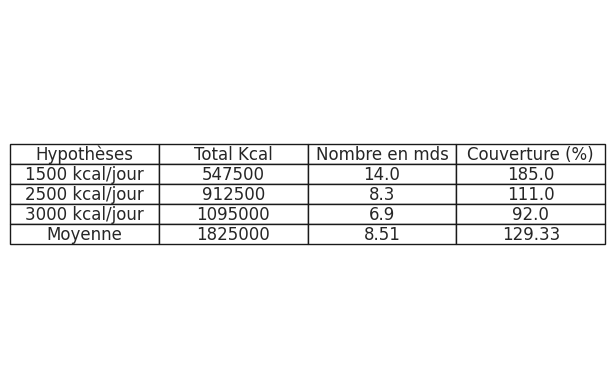

In [331]:
#Tableau des hypothèses en besoins nutritionnels et nombre de population nourries
import matplotlib.pyplot as plt
# créer un dataframe avec les chiffres ci-dessus tels que :
S1 = '1500 kcal/jour'
S2 = '2500 kcal/jour'
S3 = '3000 kcal/jour'

prop1mds = round(proportion1 ,2)
prop2mds = round(proportion2 ,2)
prop3mds = round(proportion3 ,2)

# Données à inclure dans le DataFrame
data = {
    'Hypothèses': [S1, S2, S3],
    'Total Kcal': [547500 , 912500 , 1095000 ],
    'Nombre en mds': [14 , 8.3, 6.9],
    'Couverture (%)': [185, 111, 92]
    }

# Créer le DataFrame
df_scenarios = pd.DataFrame(data)

# Calculer la moyenne
moyenne_personnes_nourries = 1825000
moyenne_calories = 8.51
moyenne_couverture = round(df_scenarios['Couverture (%)'].mean(),2)

# Ajouter la ligne pour la moyenne au DataFrame
df_scenarios.loc[len(df_scenarios)] = ['Moyenne', moyenne_personnes_nourries, moyenne_calories, moyenne_couverture]

# Afficher le DataFrame
print(df_scenarios)

# Exporter le DataFrame vers un fichier Excel
#df_scenarios.to_excel("tableau_hypotheses.xlsx", index=False)

# Créer une figure et un axe
fig, ax = plt.subplots()

# Désactiver l'axe
ax.axis('tight')
ax.axis('off')

# Créer le tableau
table = ax.table(cellText=df_scenarios.values, colLabels=df_scenarios.columns, cellLoc = 'center', loc='center')

# Personnaliser le tableau (facultatif)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)  # Ajuster la taille du tableau

# Afficher le tableau
plt.show()

#3.3 Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux

In [332]:
#transfert des données avec les végétaux dans un nouveau dataframe
#print (jointureDispoAlimentaire_Popu2017.head())

# Étape 0 : NB population 2017
Nbpopulation = df_population_2017['population'].sum()
print(format_americain(Nbpopulation))

# Calcul du nombre d'humains pouvant être nourris selon les 3 hypothèses de besoins nutritionnels par an par personne EN VEGETAL

# Étape 1 : Filtrer pour les origines végétales et calculer la disponibilité totale en kcal
jointureDispoAlimentaire_Popu2017['total_dispo_kcal_vegetale'] = (
    jointureDispoAlimentaire_Popu2017.loc[jointureDispoAlimentaire_Popu2017['Origine'] == 'vegetale',                                      'Disponibilité alimentaire (Kcal/personne/jour)'] *365
    * jointureDispoAlimentaire_Popu2017.loc[jointureDispoAlimentaire_Popu2017['Origine'] == 'vegetale', 'population']
)

# Optionnel : Remplacer les valeurs où l'origine n'est pas végétale par 0 ou NaN
jointureDispoAlimentaire_Popu2017['total_dispo_kcal_vegetale'].fillna(0, inplace=True)

# Étape 2 : Calculer la disponibilité totale en kcal vegetale mondiale
total_dispo_kcal_vegetale_mondial = jointureDispoAlimentaire_Popu2017['total_dispo_kcal_vegetale'].sum()
print(f"nombre total de disponibilité cal vegetale : {total_dispo_kcal_vegetale_mondial}  Kcal")

# Étape 3 : Calculer le nombre d'humains

#pouvant être nourris selon Hyp1
proportion11 = (jointureDispoAlimentaire_Popu2017['total_dispo_kcal_vegetale'].sum()/ Hyp1)
print(f"calcul par an du nombre de personnes nourries en végétale Hyp1 : {format_americain(proportion11)} mds pour {total_dispo_kcal_mondial}")

percentprop11 = round( proportion11/Nbpopulation *100,2)
print(f"/n soit {percentprop11} % de la population mondiale 2017 {Nbpopulation} ")

#pouvant être nourris selon Hyp2
proportion22 = (jointureDispoAlimentaire_Popu2017['total_dispo_kcal_vegetale'].sum() / Hyp2)
print(f"calcul par an du nombre de personnes nourries en végétale Hyp2 : {format_americain(proportion22)} mds pour {total_dispo_kcal_mondial}")

percentprop22 = round(proportion22/Nbpopulation *100,2)
print(f"/n soit {percentprop22} % % de la population mondiale 2017 {Nbpopulation} ")

#pouvant être nourris selon Hyp3
proportion33 = (jointureDispoAlimentaire_Popu2017['total_dispo_kcal_vegetale'].sum() / Hyp3)
print(f"calcul par an du nombre de personnes nourries en végétale Hyp3 : {format_americain(proportion33)} mds pour {total_dispo_kcal_mondial}")

percentprop33 = round(proportion33/Nbpopulation *100,2)
print(f"/n soit {percentprop33} % % de la population mondiale 2017 {Nbpopulation} ")

# Étape 3 : Calculer le nombre d'humains  en moyenne selon les 3 Hypothèses
moypercentpropbis = round((percentprop11 + percentprop22 +percentprop33) /3,2)
print(f"Moyenne Végétale de pourcentage : {moypercentprop}%   ")


7,548,134,111.00
nombre total de disponibilité cal vegetale : 6300178937197865.0  Kcal
calcul par an du nombre de personnes nourries en végétale Hyp1 : 11,507,176,141.00 mds pour 7635429388975815.0
/n soit 152.45 % de la population mondiale 2017 7548134111.0 
calcul par an du nombre de personnes nourries en végétale Hyp2 : 6,904,305,684.60 mds pour 7635429388975815.0
/n soit 91.47 % % de la population mondiale 2017 7548134111.0 
calcul par an du nombre de personnes nourries en végétale Hyp3 : 5,753,588,070.50 mds pour 7635429388975815.0
/n soit 76.23 % % de la population mondiale 2017 7548134111.0 
Moyenne Végétale de pourcentage : 129.33%   


/tmp/ipython-input-2545328803.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  jointureDispoAlimentaire_Popu2017['total_dispo_kcal_vegetale'].fillna(0, inplace=True)


       Hypothèses  Kcal Végétales   Nombre en mds  Couverture (%)
0  1500 kcal/jour         547500.0          12.00          152.00
1  2500 kcal/jour         912500.0           7.00           91.00
2  3000 kcal/jour        1095000.0           6.00           76.00
3         Moyenne         851667.0           8.16          106.33


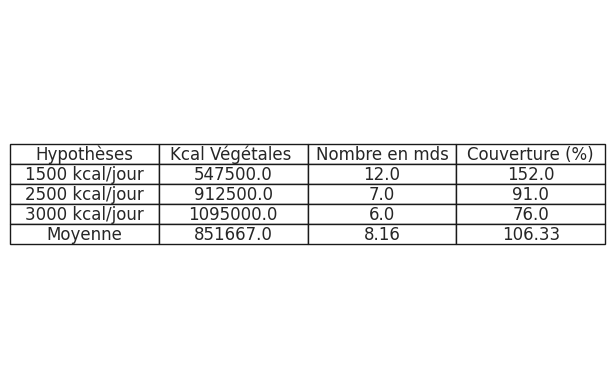

In [333]:
#Tableau des hypothèses en besoins nutritionnels et nombre de population nourries en vétéale
# créer un dataframe avec les chiffres ci-dessus tels que :
S1 = '1500 kcal/jour'
S2 = '2500 kcal/jour'
S3 = '3000 kcal/jour'

prop1mds = round(proportion11 ,2)
prop2mds = round(proportion22 ,2)
prop3mds = round(proportion33 ,2)

# Données à inclure dans le DataFrame
data = {
    'Hypothèses': [S1, S2, S3],
    'Kcal Végétales ': [547500 , 912500 , 1095000 ],
    'Nombre en mds': [12 , 7, 6],
    'Couverture (%)': [152, 91, 76]
    }

# Créer le DataFrame
df_scenarios = pd.DataFrame(data)

# Calculer la moyenne
moyenne_personnes_nourries = 8.16 #(round(11.5+7+6,2) /3)/1000000000 # 8,16 mds
moyenne_calories = round((547500 +912500+1095000)/3 ,0) #((547500 + 912500 +1095000)/3/1000000000) # 851 666 cal
moyenne_couverture =round((152+91+76)/3,2) #round(df_scenarios['Couverture (%)'].mean(),2) # 106,7

# Ajouter la ligne pour la moyenne au DataFrame
df_scenarios.loc[len(df_scenarios)] = ['Moyenne',  moyenne_calories, moyenne_personnes_nourries,moyenne_couverture]

# Afficher le DataFrame
print(df_scenarios)

# Exporter le DataFrame vers un fichier Excel
df_scenarios.to_excel("tableau_hypotheses.xlsx", index=False)

# Créer une figure et un axe
fig, ax = plt.subplots()

# Désactiver l'axe
ax.axis('tight')
ax.axis('off')

# Créer le tableau
table = ax.table(cellText=df_scenarios.values, colLabels=df_scenarios.columns, cellLoc = 'center', loc='center')

# Personnaliser le tableau (facultatif)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)  # Ajuster la taille du tableau

# Afficher le tableau
plt.show()

In [334]:
#calcul du nombre de kcal disponible pour les végétaux
# Étape 2 : Calculer la disponibilité totale en kcal mondial
total_dispo_kcal_mondial_vegetale = jointureDispoAlimentaire_Popu2017['total_dispo_kcal_vegetale'].sum() * 365
print(f"Le nombre de kcal disponible pour les végétaux est de :{format_americain(total_dispo_kcal_mondial_vegetale)}" )

Le nombre de kcal disponible pour les végétaux est de :2,299,565,312,077,220,608.00


In [335]:
#calcul du nombre d'humains pouvant être nourris avec les végétaux

# Étape 4 : Calculer le nombre d'humains pouvant être nourris
calculHumanVeggie = total_dispo_kcal_mondial_vegetale / 912500.0
propHuman2 = round( calculHumanVeggie / Nbpopulation * 100 ,2)
print(f"Somme de popu / dispo_kcal mondial vegetale : {format_americain(calculHumanVeggie)}")
print(f"Proportion modialevegetale : {format_americain(propHuman2)}")

Somme de popu / dispo_kcal mondial vegetale : 2,520,071,574,879.15
Proportion modialevegetale : 33,386.68


#3.4 Utilisation de la disponibilité intérieure

In [336]:
#calcul de la disponibilité totale
# Disponibilité intérieure = Productions + importations - exportations + Variation de Stock
TotalDispoInterieure = jointureDispoAlimentaire_Popu2017['Production'].sum() + jointureDispoAlimentaire_Popu2017['Importations - Quantité'].sum() - jointureDispoAlimentaire_Popu2017['Exportations - Quantité'].sum() + jointureDispoAlimentaire_Popu2017['Variation de stock'].sum()

print(f"Calcul de la disponiblité totale par la somme de toute les lignes de disponibilité intérieure {format_americain(TotalDispoInterieure)}")

# donner la part de l'alimentation humaine
partAlimentationHumaine = jointureDispoAlimentaire_Popu2017['Nourriture'].sum() /TotalDispoInterieure * 100

print(f"Calcul de la part de l'alimentation humaine {format_americain(partAlimentationHumaine)}%")

# donner la part de l'alimentation animale
partAlimentationAnimale =jointureDispoAlimentaire_Popu2017['Aliments pour animaux'].sum() /TotalDispoInterieure * 100

print(f"Calcul de la part de l'alimentation animale {format_americain(partAlimentationAnimale)}%")

# donner la part de l'alimentation perdue
partAlimentationPerdue =jointureDispoAlimentaire_Popu2017['Pertes'].sum() /TotalDispoInterieure * 100

print(f"Calcul de la part de l'alimentation perdue {format_americain(partAlimentationPerdue)}%")

# donner la part des semences
partAlimentationSemences =jointureDispoAlimentaire_Popu2017['Semences'].sum() /TotalDispoInterieure * 100

print(f"Calcul de la part des semences {format_americain(partAlimentationSemences)}%")

# donner la part des Traitements
partAlimentationTraitement =jointureDispoAlimentaire_Popu2017['Traitement'].sum() /TotalDispoInterieure * 100

print(f"Calcul de la part des traitements {format_americain(partAlimentationTraitement)}%")

# donner la part des autres utilisations
partAlimentationAutresUtilisations =jointureDispoAlimentaire_Popu2017['Autres Utilisations'].sum() /TotalDispoInterieure * 100

print(f"Calcul de la part des Autres utilisations {format_americain(partAlimentationAutresUtilisations)}%")

Calcul de la disponiblité totale par la somme de toute les lignes de disponibilité intérieure 9,734,105,000,000.00
Calcul de la part de l'alimentation humaine 49.37%
Calcul de la part de l'alimentation animale 13.23%
Calcul de la part de l'alimentation perdue 4.65%
Calcul de la part des semences 1.58%
Calcul de la part des traitements 22.45%
Calcul de la part des Autres utilisations 8.82%


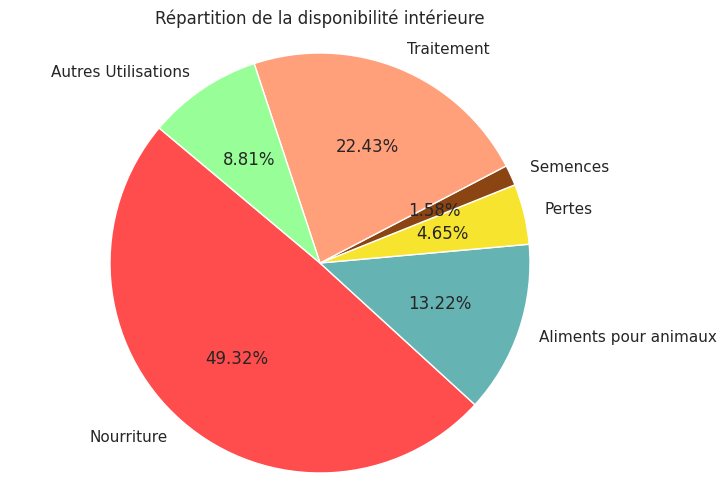

In [337]:
import matplotlib.pyplot as plt

# Données calculées
labels = ['Nourriture', 'Aliments pour animaux', 'Pertes', 'Semences', 'Traitement', 'Autres Utilisations']
sizes = [49.37, 13.23, 4.65, 1.58, 22.45, 8.82]
colors1 = ['#FF4C4C', '#66B3B3', '#F6E42E', '#8B4513', '#FFA07A', '#98FF98']  # Ajout de deux couleurs supplémentaires

# Créer le camembert
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors1, autopct='%1.2f%%', startangle=140)

# Égaliser le rapport pour un cercle parfait
plt.axis('equal')

# Titre
plt.title('Répartition de la disponibilité intérieure')

# Afficher le camembert
plt.show()

In [338]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures,
# Itération sur chaque ligne du DataFrame

total_dispo_interieure_aliments = 0
total_dispo_interieure_Pertes = 0
total_dispo_interieure_Nourriture = 0
total_dispo_interieure_Semences = 0
total_dispo_interieure_Traitement = 0
total_dispo_interieure_Autres_utilisations = 0

for index, row in jointureDispoAlimentaire_Popu2017.iterrows():
    # Vérification pour chaque colonne d'intérêt
    for col in ['Aliments pour animaux', 'Pertes', 'Nourriture']:
        # Récupérer la valeur de la colonne courante
        valeur = row[col]
        if valeur > 0 and col=='Aliments pour animaux':
          total_dispo_interieure_aliments += row[col]
        if valeur > 0 and col=='Pertes':
          total_dispo_interieure_Pertes += row[col]
        if valeur > 0 and col=='Nourriture':
          total_dispo_interieure_Nourriture += row[col]
        if valeur > 0 and col=='Semences':
          total_dispo_interieure_Semences += row[col]
        if valeur > 0 and col=='Traitement':
          total_dispo_interieure_Traitement += row[col]
        if valeur > 0 and col=='Autes utilisations':
          total_dispo_interieure_Autres_utilisations += row[col]

print (f"Total dispo interieure Aliments pour animaux {format_americain(total_dispo_interieure_aliments)} ")

print (f"Total dispo interieure Pertes  {format_americain(total_dispo_interieure_Pertes)} ")

print (f"Total dispo interieure Nourriture {format_americain(total_dispo_interieure_Nourriture)} ")

print (f"Total dispo interieure Semences {format_americain(total_dispo_interieure_Semences)} ")

print (f"Total dispo interieure Traitement {format_americain(total_dispo_interieure_Traitement)} ")

print (f"Total dispo interieure Autres utilisations {format_americain(total_dispo_interieure_Autres_utilisations)} ")

print (f"Total dispo interieure tte catégorie {format_americain(total_dispo_interieure_aliments + total_dispo_interieure_Pertes + total_dispo_interieure_Nourriture )} ")

Total dispo interieure Aliments pour animaux 1,288,002,000,000.00 
Total dispo interieure Pertes  452,283,000,000.00 
Total dispo interieure Nourriture 4,805,771,000,000.00 
Total dispo interieure Semences 0.00 
Total dispo interieure Traitement 0.00 
Total dispo interieure Autres utilisations 0.00 
Total dispo interieure tte catégorie 6,546,056,000,000.00 


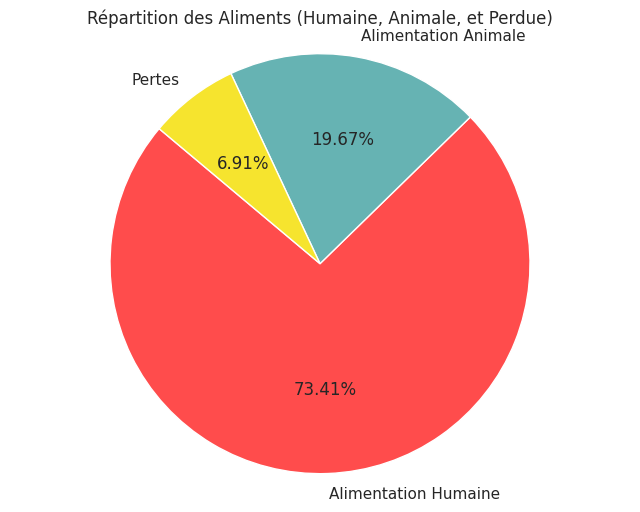

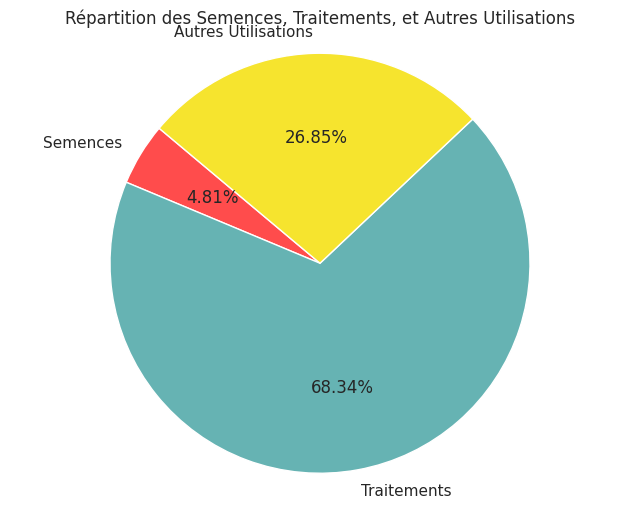

In [339]:
#regroupement sur un même graphique de deux camemberts
import matplotlib.pyplot as plt

# Données pour le premier camembert (Alimentation Humaine, Animale, et Perdue)
labels1 = ['Alimentation Humaine', 'Alimentation Animale', 'Pertes']
sizes1 = [49.37, 13.23, 4.65]

# Couleurs pour le premier camembert
colors1 = ['#FF4C4C', '#66B3B3','#F6E42E', '#8B4513']

# Créer le premier camembert
plt.figure(figsize=(8, 6))
plt.pie(sizes1, labels=labels1, colors=colors1, autopct='%1.2f%%', startangle=140)
plt.axis('equal')  # Pour faire un camembert circulaire
plt.title('Répartition des Aliments (Humaine, Animale, et Perdue)')
plt.show()

# Données pour le second camembert (Semences, Traitements, et Autres Utilisations)
labels2 = ['Semences', 'Traitements', 'Autres Utilisations']
sizes2 = [1.58, 22.45, 8.82]

# Couleurs pour le second camembert
colors2 = ['#FF4C4C', '#66B3B3','#F6E42E', '#8B4513']

# Créer le second camembert
plt.figure(figsize=(8, 6))
plt.pie(sizes2, labels=labels2, colors=colors2, autopct='%1.2f%%', startangle=140)
plt.axis('equal')  # Pour faire un camembert circulaire
plt.title('Répartition des Semences, Traitements, et Autres Utilisations')
plt.show()


#3.5 Utilisation des céréales

In [340]:
#Création d'une liste avec toutes les variables
Liste_variables = []
for index, row in jointureDispoAlimentaire_Popu2017.iterrows():
  if  row['Origine'] == 'vegetale':
    #print(f"Ajout: {row['Produit']}")
    Liste_variables.append(row['Produit'])

Liste_unique = list(set(Liste_variables))
print(f"Liste des variables :{Liste_unique}")



Liste des variables :['Céréales, Autres', 'Plantes Oleiferes, Autre', 'Noix', 'Graines Colza/Moutarde', 'Soja', 'Raisin', 'Huile de Palmistes', 'Agrumes, Autres', 'Légumes, Autres', 'Alcool, non Comestible', 'Oranges, Mandarines', 'Pommes', 'Huile de Son de Riz', 'Fruits, Autres', 'Edulcorants Autres', 'Miel', 'Piments', 'Avoine', 'Tomates', 'Aliments pour enfants', 'Maïs', 'Pois', 'Huil Plantes Oleif Autr', 'Huile de Sésame', 'Citrons & Limes', 'Graines de coton', 'Coco (Incl Coprah)', 'Thé', 'Huile de Coco', 'Huile de Tournesol', 'Bananes', 'Huile de Soja', 'Sésame', 'Haricots', 'Pommes de Terre', 'Ananas', 'Huile Graines de Coton', 'Poivre', 'Orge', 'Palmistes', 'Dattes', 'Sucre Eq Brut', 'Blé', "Huile d'Arachide", 'Café', 'Bière', 'Sorgho', 'Huile de Colza&Moutarde', 'Huile de Palme', 'Vin', 'Bananes plantains', 'Manioc', 'Boissons Alcooliques', 'Millet', 'Sucre, canne', 'Arachides Decortiquees', 'Olives', 'Boissons Fermentés', 'Huile de Germe de Maïs', 'Pamplemousse', 'Légumineuse

In [341]:
#création d'un dataframe avec les informations uniquement pour les céréales
Liste_cereales =['Céréales, Autres',
                 'Millet',
                 'Seigle',
                 'Avoine',
                 'Maîs',
                 'Orge',
                 'Sorgho',
                 'Blé',
                 'Riz (Eq Blanchi)']
dataCereales = jointureDispoAlimentaire_Popu2017[jointureDispoAlimentaire_Popu2017['Produit'].isin(Liste_cereales )]

print(dataCereales.head())



           Zone           Produit   Origine  Aliments pour animaux  \
7   Afghanistan               Blé  vegetale                    0.0   
12  Afghanistan  Céréales, Autres  vegetale                    0.0   
34  Afghanistan            Millet  vegetale                    0.0   
40  Afghanistan              Orge  vegetale            360000000.0   
47  Afghanistan  Riz (Eq Blanchi)  vegetale                    0.0   

    Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
7                   0.0                                          1369.0   
12                  0.0                                             0.0   
34                  0.0                                             3.0   
40                  0.0                                            26.0   
47                  0.0                                           141.0   

    Disponibilité alimentaire en quantité (kg/personne/an)  \
7                                              160.23        
12  

Total des céréales pour l'alimentation humaine : 895,464,000,000.00
Part alim. humaine pour le Millet dans: 2.57%
Part alim. humaine pour le Céréales, Autres dans: 0.59%
Part alim. humaine pour le Orge dans: 0.75%
Part alim. humaine pour le Blé dans: 50.32%
Part alim. humaine pour le Seigle dans: 0.6%
Part alim. humaine pour le Riz (Eq Blanchi) dans: 42.08%
Part alim. humaine pour le Sorgho dans: 2.7%
Part alim. humaine pour le Avoine dans: 0.39%
Longueur de sizes: 8, Longueur de labels: 8


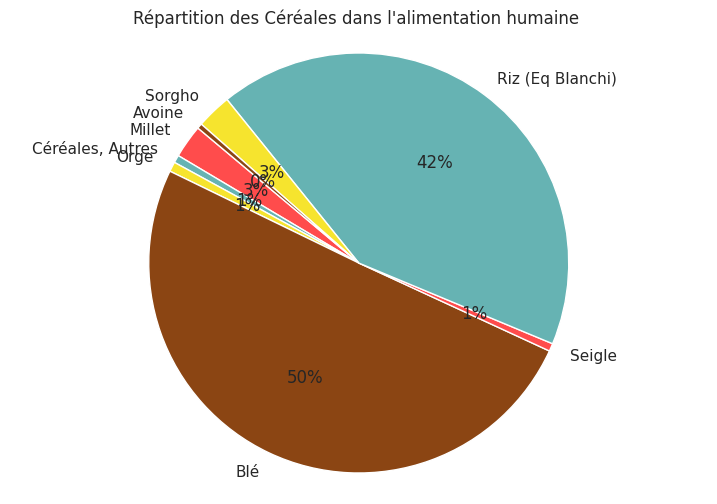

In [342]:
#affichage de la proportion des  céréales dans l'alimentation humaine
import matplotlib.pyplot as plt

# Affichage de la proportion des céréales dans l'alimentation humaine

# Calculer le total d'alimentation animale dans le dataframe cereales
TotalcerealesAnimales = dataCereales['Nourriture'].sum()
print(f"Total des céréales pour l'alimentation humaine : {format_americain(TotalcerealesAnimales)}")

# Créer un set à partir des valeurs uniques de la colonne
unique_cereales = set(dataCereales['Produit'])
data_dict = {}

# Utilisation de la boucle For pour calculer et afficher la proportion
for i in unique_cereales:
    filtre_unique_cereales = dataCereales[dataCereales['Produit'] == str(i)]

    if not filtre_unique_cereales.empty:
        part_alim = round(filtre_unique_cereales['Nourriture'].sum() / TotalcerealesAnimales * 100, 2)
        print(f"Part alim. humaine pour le {i} dans: {part_alim}%")

        # Ajouter ou cumuler dans le dictionnaire
        if str(i) in data_dict:
            data_dict[str(i)] += part_alim
        else:
            data_dict[str(i)] = part_alim

# On convertit le dictionnaire en listes
sizes = list(data_dict.values())
labels = list(data_dict.keys())

# Affichage en graphiques grâce à la librairie MatPlotLib

# On vérifie les longueurs
print(f"Longueur de sizes: {len(sizes)}, Longueur de labels: {len(labels)}")

# Couleurs pour le premier camembert
# Couleurs pour le premier camembert
colors1 = ['#FF4C4C', '#66B3B3','#F6E42E', '#8B4513']

# Créer le camembert seulement si les longueurs correspondent
if len(sizes) == len(labels) and len(sizes) > 0:
    plt.figure(figsize=(9, 6))
    # Créer le camembert
    wedges, texts, autotexts = plt.pie(sizes, labels=labels, colors = colors1, autopct='%1.0f%%', startangle=140)

    # Égaliser le rapport pour un cercle parfait
    plt.axis('equal')

    # Titre
    plt.title('Répartition des Céréales dans l\'alimentation humaine ')

    # Afficher le camembert
    plt.show()



Total des céréales pour l'alimentation des animaux : 314,869,000,000.00
Part alim. animaux pour le Millet dans: 1.04%
Part alim. animaux pour le Céréales, Autres dans: 5.97%
Part alim. animaux pour le Orge dans: 28.2%
Part alim. animaux pour le Blé dans: 38.65%
Part alim. animaux pour le Seigle dans: 2.56%
Part alim. animaux pour le Riz (Eq Blanchi) dans: 10.67%
Part alim. animaux pour le Sorgho dans: 7.87%
Part alim. animaux pour le Avoine dans: 5.04%
Longueur de sizes: 8, Longueur de labels: 8


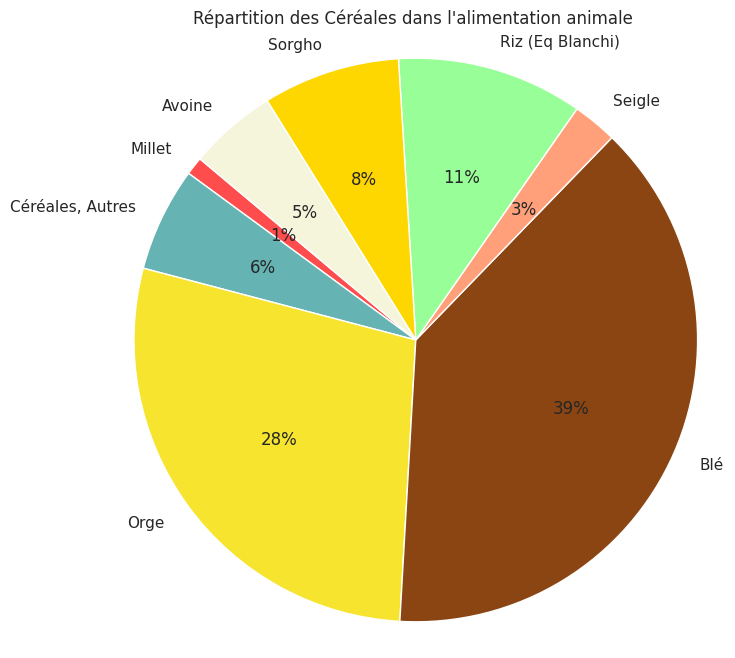

In [343]:
#affichage de la proportion d'alimentation animale

# Calculer le total d'alimentation animale dans le dataframe cereales
TotalcerealesAnimales = dataCereales['Aliments pour animaux'].sum()
print(f"Total des céréales pour l'alimentation des animaux : {format_americain(TotalcerealesAnimales)}")

# Créer un set à partir des valeurs uniques de la colonne
unique_cereales = set(dataCereales['Produit'])
#print(unique_cereales)

# Dictionnaire pour stocker les valeurs uniques parcourues dans la boucle For
data_dict = {}

# utilisation de la boucle For pour calculer et afficher la proportion
for i in unique_cereales:
    # Filtrer le DataFrame pour obtenir les lignes pertinentes
    filtre_unique_cereales = dataCereales[dataCereales['Produit'] == str(i)]

    # Vérifier si des données existent pour éviter des erreurs
    if not filtre_unique_cereales.empty:
        # Calculer la proportion en alimentation animale
        part_alim = round(filtre_unique_cereales['Aliments pour animaux'].sum() / TotalcerealesAnimales * 100,2)
        print(f"Part alim. animaux pour le {i} dans: {part_alim}%")
        # on ajoute ou on cumule dans le dictionnaire
        if str(i) in data_dict:
            data_dict[str(i)] += part_alim  # uniquement si différent
        else:
            data_dict[str(i)] = part_alim  # sinon on passe

# On convertit le dictionnaire en listes
sizes = list(data_dict.values())
labels = list(data_dict.keys())

#affichage en graphiques grâce à la librairie MatPlotLib
# On vérifie les longueurs
print(f"Longueur de sizes: {len(sizes)}, Longueur de labels: {len(labels)}")

# Couleurs pour le premier camembert
colors1 = ['#FF4C4C', '#66B3B3','#F6E42E', '#8B4513','#FFA07A','#98FF98','#FFD700','#F5F5DC']

# Créer le camembert seulement si les longueurs correspondent
if len(sizes) == len(labels) and len(sizes) > 0:
    plt.figure(figsize=(8, 8))
    # Créer le camembert
    wedges, texts, autotexts = plt.pie(sizes, labels=labels,colors=colors1, autopct='%1.0f%%', startangle=140)

    # Égaliser le rapport pour un cercle parfait
    plt.axis('equal')

    # Titre
    plt.title('Répartition des Céréales dans l\'alimentation animale ')

    # Afficher le camembert
    plt.show()

Total des céréales pour l'alimentation humaine : 895,464,000,000.00
Part alimentation humaine pour le Millet dans: 2.57%
Part alimentation humaine pour le Céréales, Autres dans: 0.59%
Part alimentation humaine pour le Orge dans: 0.75%
Part alimentation humaine pour le Blé dans: 50.32%
Part alimentation humaine pour le Seigle dans: 0.6%
Part alimentation humaine pour le Riz (Eq Blanchi) dans: 42.08%
Part alimentation humaine pour le Sorgho dans: 2.7%
Part alimentation humaine pour le Avoine dans: 0.39%
Longueur de sizes: 8, Longueur de labels: 8


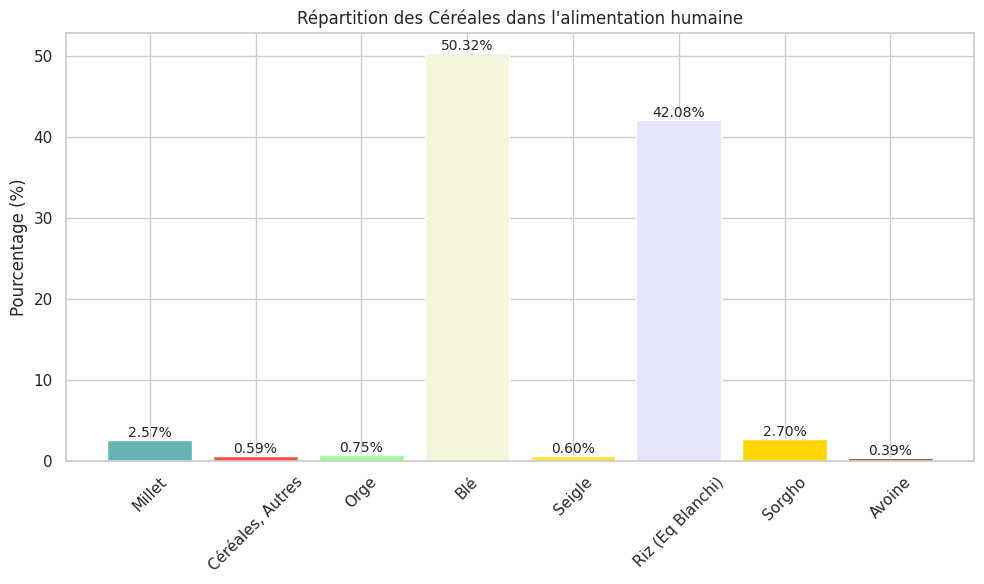

In [344]:
import matplotlib.pyplot as plt

# Calculer le total d'alimentation humaine dans le dataframe cereales
TotalcerealesAnimales = dataCereales['Nourriture'].sum()
print(f"Total des céréales pour l'alimentation humaine : {format_americain(TotalcerealesAnimales)}")

# Créer un set à partir des valeurs uniques de la colonne
unique_cereales = set(dataCereales['Produit'])

# Dictionnaire pour stocker les valeurs uniques parcourues dans la boucle For
data_dict = {}


# Utilisation de la boucle For pour calculer et afficher la proportion
for i in unique_cereales:
    # Filtrer le DataFrame pour obtenir les lignes pertinentes
    filtre_unique_cereales = dataCereales[dataCereales['Produit'] == str(i)]

    # Vérifier si des données existent pour éviter des erreurs
    if not filtre_unique_cereales.empty:
        # Calculer la proportion en alimentation humaine
        part_alim = round(filtre_unique_cereales['Nourriture'].sum() / TotalcerealesAnimales * 100, 2)
        print(f"Part alimentation humaine pour le {i} dans: {part_alim}%")
        # On ajoute ou on cumule dans le dictionnaire
        if str(i) in data_dict:
            data_dict[str(i)] += part_alim  # uniquement si différent
        else:
            data_dict[str(i)] = part_alim  # sinon on passe

# On convertit le dictionnaire en listes
sizes = list(data_dict.values())
labels = list(data_dict.keys())

# Affichage en graphiques grâce à la librairie MatPlotLib
# On vérifie les longueurs
print(f"Longueur de sizes: {len(sizes)}, Longueur de labels: {len(labels)}")

# Créer l'histogramme seulement si des données existent
if len(sizes) == len(labels) and len(sizes) > 0:
    plt.figure(figsize=(10, 6))
    # Exemple de correspondance produit-couleur
    #colors1 = ['#FF4C4C', '#66B3B3','#F6E42E', '#8B4513','#FFA07A','#98FF98','#FFD700','#F5F5DC']
    couleur_map = {
                  'Céréales, Autres': '#FF4C4C',
                  'Millet':'#66B3B3',
                  'Seigle':'#F6E42E',
                  'Avoine':'#8B4513',
                  'Maîs':'#FFA07A',
                  'Orge':'#98FF98',
                  'Sorgho':'#FFD700',
                  'Blé':'#F5F5DC',
                  'Riz (Eq Blanchi)':'#E6E6FA'
   }
    # Créer la liste des couleurs en fonction des labels
    colors = [couleur_map.get(label, 'gray') for label in labels]
    bars = plt.bar(labels, sizes, color = colors)  # associer les couleurs aux barres

    # Ajouter des étiquettes sur les barres
    for bar in bars:
        yval = bar.get_height()  # Obtenez la hauteur de chaque barre
        plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}%',
                 ha='center', va='bottom', fontsize=10)  # Affiche la valeur

    # Personnalisation de l'histogramme
    plt.xticks(rotation=45)  # Faire pivoter les labels pour la lisibilité
    plt.ylabel('Pourcentage (%)')
    plt.title('Répartition des Céréales dans l\'alimentation humaine')

    # Afficher le graphique
    plt.tight_layout()  # Ajuste l'affichage
    plt.show()
else:
    print("Les longueurs de sizes et labels ne correspondent pas ou sont vides.")

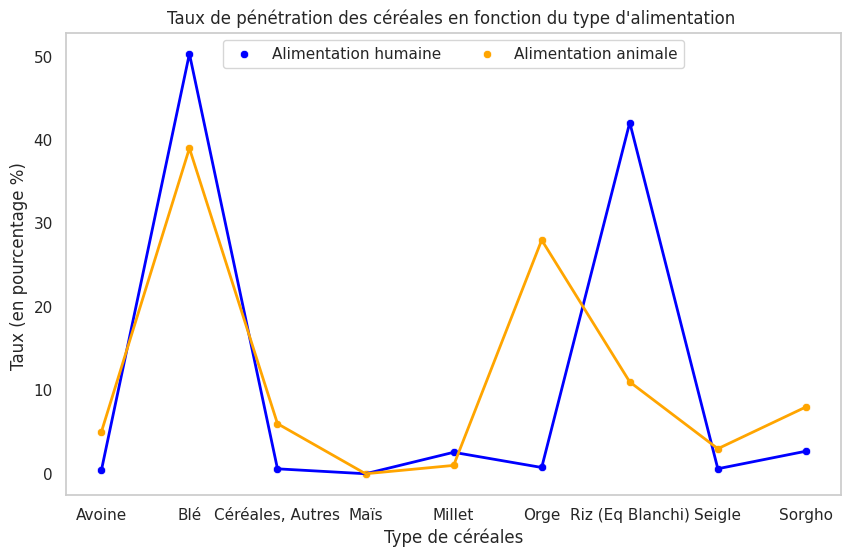

In [345]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#palette de coulors
couleur_map = {
                  'Céréales, Autres': '#FF4C4C',
                  'Millet':'#66B3B3',
                  'Seigle':'#F6E42E',
                  'Avoine':'#8B4513',
                  'Maîs':'#FFA07A',
                  'Orge':'#98FF98',
                  'Sorgho':'#FFD700',
                  'Blé':'#F5F5DC',
                  'Riz (Eq Blanchi)':'#E6E6FA'
   }

#  dictionnaire1 de données alimentation humaine
data_dict1= {
    'Céréales, Autres': 0.59,
    'Millet': 2.57,
    'Seigle': 0.60,
    'Avoine': 0.39,
    'Maïs': 0,
    'Orge': 0.75,
    'Sorgho': 2.70,
    'Blé': 50.32,
    'Riz (Eq Blanchi)': 42.08
}
#  dictionnaire2 de données alimentation animale
data_dict2 = {
    'Céréales, Autres': 6,
    'Millet': 1,
    'Seigle': 3,
    'Avoine': 5,
    'Maïs': 0,
    'Orge': 28,
    'Sorgho': 8,
    'Blé': 39,
    'Riz (Eq Blanchi)': 11
}

# Conversion du dictionnaire en DataFrame
df1 = pd.DataFrame(list(data_dict1.items()), columns=['Céréales', 'Taux_dt1'])
df2 = pd.DataFrame(list(data_dict2.items()), columns=['Céréales', 'Taux_dt2'])

# Combiner les DataFrames
df_combined = pd.merge(df1, df2, on='Céréales', how='outer')

# Affichage en graphiques grâce à la librairie MatPlotLib
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 12})

# Tracer les deux sets de données
sns.scatterplot(data=df_combined, x='Céréales', y='Taux_dt1', color='blue', label='Alimentation humaine')
sns.scatterplot(data=df_combined, x='Céréales', y='Taux_dt2', color='orange', label='Alimentation animale')

# Ajouter les lignes pour relier les points
sns.lineplot(data=df_combined, x='Céréales', y='Taux_dt1', color='blue', linewidth=2)
sns.lineplot(data=df_combined, x='Céréales', y='Taux_dt2', color='orange', linewidth=2)

plt.ylabel("Taux (en pourcentage %) ")
plt.xlabel('Type de céréales')
plt.grid()
#plt.legend(loc='best')
# Personnalisation de la légende
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncol=2)
plt.title("Taux de pénétration des céréales en fonction du type d'alimentation ")
plt.show()

# 3.6 Pays avec la proportion de personnes sous-alimentée la plus forte en 2017

In [346]:
#création de la colonne proportion par pays

# Création DataFrame sous_nutrition
data_sous_nutrition = {
    'Zone': sous_nutrition['Zone'],
    'sous-nutrition': sous_nutrition['sous-nutrition']
   }
sous_nutrition = pd.DataFrame(data_sous_nutrition)

# Création de DataFrame population
data_population = {
    'Zone': population['Zone'],
    'population': population['population']
}
population = pd.DataFrame(data_population)


# Création de la colonne proportion par pays
totalPaysSousnutrition = sous_nutrition.groupby('Zone')['sous-nutrition'].sum().fillna(0).reset_index()
totalPayspopulation = population.groupby('Zone')['population'].sum().fillna(0).reset_index()

# Créer le DataFrame correctement
df_pays_sousalimentes = pd.merge( totalPaysSousnutrition, totalPayspopulation, left_on='Zone', right_on='Zone', how='inner' )

df_pays_sousalimentes['%sous-nutrition'] = df_pays_sousalimentes['sous-nutrition'] / df_pays_sousalimentes['population'] * 100

df_pays_sousalimentes = df_pays_sousalimentes.sort_values(by ='%sous-nutrition', ascending=False)

# Afficher les 10 premières lignes
print(df_pays_sousalimentes.head(10))


                                           Zone  sous-nutrition   population  \
72                                        Haïti      31200000.0   64590740.0   
151  République populaire démocratique de Corée      68100000.0  151458214.0   
99                                   Madagascar      57800000.0  147512426.0   
95                                      Libéria      10200000.0   27188056.0   
174                                       Tchad      32000000.0   86051116.0   
177                                 Timor-Leste       2400000.0    7254447.0   
143                                      Rwanda      22700000.0   69215997.0   
91                                      Lesotho       3900000.0   12405888.0   
112                                  Mozambique      49500000.0  164863908.0   
161                                Sierra Leone      12300000.0   43520450.0   

     %sous-nutrition  
72         48.304138  
151        44.962896  
99         39.183140  
95         37.516474  
174 

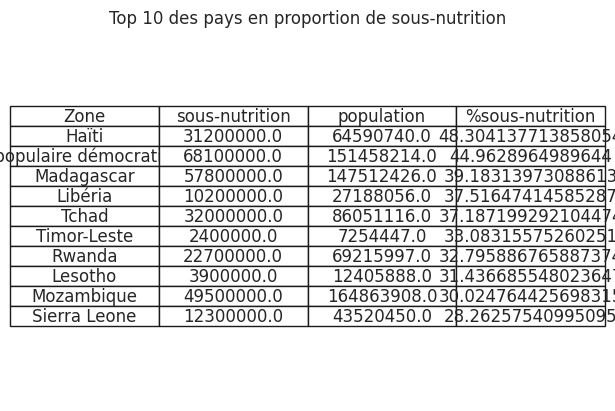

In [347]:
# Créer une figure et un axe
fig, ax = plt.subplots()

# Désactiver l'axe
ax.axis('tight')
ax.axis('off')

# Créer le tableau
table = ax.table(cellText=df_pays_sousalimentes.head(10).values, colLabels=df_pays_sousalimentes.head(10).columns, cellLoc = 'center', loc='center')

# Personnaliser le tableau (facultatif)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)  # Ajuster la taille du tableau

# Afficher le tableau
plt.title('Top 10 des pays en proportion de sous-nutrition')
plt.show()

              Zone  sous-nutrition   population  %sous-nutrition
72           Haïti      31200000.0   64590740.0        48.304138
151  Corée du Nord      68100000.0  151458214.0        44.962896
99      Madagascar      57800000.0  147512426.0        39.183140
95         Libéria      10200000.0   27188056.0        37.516474
174          Tchad      32000000.0   86051116.0        37.187199
177    Timor-Leste       2400000.0    7254447.0        33.083156
143         Rwanda      22700000.0   69215997.0        32.795887
91         Lesotho       3900000.0   12405888.0        31.436686
112     Mozambique      49500000.0  164863908.0        30.024764
161   Sierra Leone      12300000.0   43520450.0        28.262575
Longueur de sizes: 10, Longueur de labels: 10


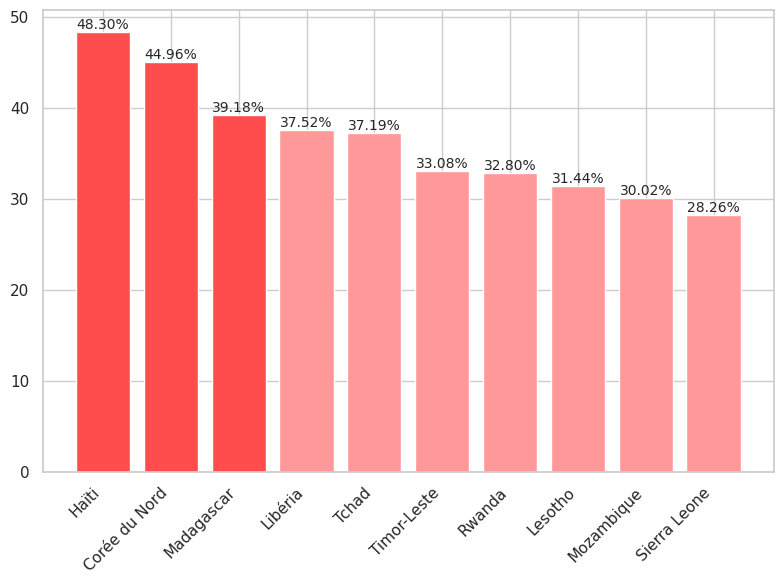

In [348]:
# Affichage des 10 pires pays après tri
pays_sous_alimente  =df_pays_sousalimentes.sort_values(by ='%sous-nutrition', ascending= False ).head(10)

# Filtrer les pays avec des valeurs de sous-nutrition > 0
filtre_pays_loc = pays_sous_alimente[pays_sous_alimente['%sous-nutrition'] > 0]

# Supprimer les doublons de sous-nutrition tout en gardant la première occurrence
filtre_pays_loc = pays_sous_alimente.drop_duplicates(subset='%sous-nutrition', keep='first')

# Dictionnaire de remplacements
remplacements = {
    'Haïti' : 'Haïti',
    'République populaire démocratique de Corée' : 'Corée du Nord',
    'Madagascar': 'Madagascar',
    'Libéria': 'Libéria',
    'Tchad': 'Tchad',
    'Rwanda': 'Rwanda',
    'Lesotho': 'Lesotho',
    'Mozambique': 'Mozambique',
    'Sierra Leone': 'Sierra Leone',
}

pays_sous_alimente['Zone'] = pays_sous_alimente['Zone'].replace(remplacements)

# Prendre les 10 premiers pays (après suppression des doublons)
top_pays_sous_alimente = pays_sous_alimente.head(10)

# Afficher les pays sélectionnés
print(top_pays_sous_alimente)

# Récupérer les valeurs pour le camembert
sizes = list(top_pays_sous_alimente['%sous-nutrition'])
labels = list(top_pays_sous_alimente['Zone'])

# Affichage en graphiques grâce à la librairie MatPlotLib
# On vérifie les longueurs
print(f"Longueur de sizes: {len(sizes)}, Longueur de labels: {len(labels)}")

# Créer l'histogramme seulement si des données existent
if len(sizes) == len(labels) and len(sizes) > 0:
    plt.figure(figsize=(8, 6))
    # Exemple de correspondance produit-couleur
    couleur_map = {
                  'Haïti': '#FF4C4C',
                  'Corée du nord':'#FF4C4C',
                  'Madagascar':'#FF4C4C',
                  'Libéria':'#ff9999',
                  'Tchad':'#ff9999',
                  'Timor-Leste':'#ff9999',
                  'Rwanda':'#ff9999',
                  'Lesotho':'#ff9999',
                  'Mozambique':'#ff9999',
                  'Sierra Leone' : '#ff9999'
   }
    # Créer la liste des couleurs en fonction des labels
    colors = [couleur_map.get(label, '#FF4C4C') for label in labels]
    bars = plt.bar(labels, sizes, color = colors)  # associer les couleurs aux barres

    # Ajouter des étiquettes sur les barres
    for bar in bars:
        yval = bar.get_height()  # Obtenez la hauteur de chaque barre
        plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}%',
                 ha='center', va='bottom', fontsize=10)  # Affiche la valeur

    # Personnalisation de l'histogramme
    plt.xticks(rotation=45, ha = 'right')  # Faire pivoter les labels pour la lisibilité
   # plt.ylabel('Zone')
    #plt.title('Top10 des pires pays le plus en sous-alimentation')

    # Afficher le graphique
    plt.tight_layout()  # Ajuste l'affichage
    plt.show()
else:
    print("Les longueurs de sizes et labels ne correspondent pas ou sont vides.")

#3.7 Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013

In [349]:
#calcul du total de l'aide alimentaire par pays
aide_agregée = aide_alimentaire.groupby('zone')['Valeur'].sum().reset_index()

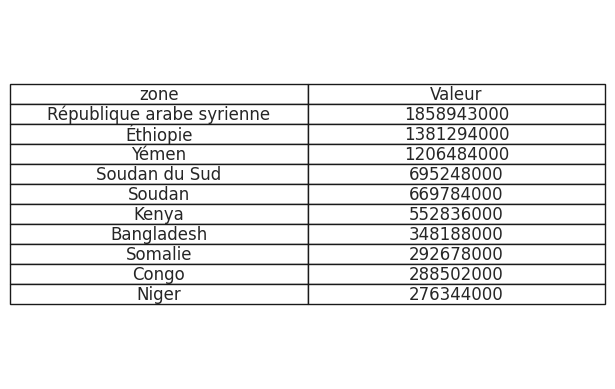

In [350]:
#affichage après tri des 10 pays qui ont bénéficié le plus de l'aide alimentaire
# Dictionnaire de remplacements
remplacements = {
    'République centrafricaine' : 'République centrafricaine',
    'Zambie' : 'Zambie',
    'Madagascar': 'Madagascar',
    'Afghanistan': 'Afghanistan',
    'Haïti': 'Haïti',
    'République démocratique du Congo': 'Congo',
    'Tchad': 'Tchad',
    'Zimbabwe': 'Zimbabwe',
    'Ouganda': 'Ouganda',
    'Ethiopie': 'Ethiopie',
}
pays_max_aide = aide_agregée.sort_values(by='Valeur', ascending=False).head(10)
#print(f"avant remplacement {pays_max_aide.head(10)}")

pays_max_aide['zone'] = pays_max_aide['zone'].replace(remplacements)
#print(f"après remplacement {pays_max_aide.head(10)}")

fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=pays_max_aide.values, colLabels=pays_max_aide.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
#plt.title('Tableau des pays ayant eu le plus d\'aide alimentaire depuis 2013')
plt.show()


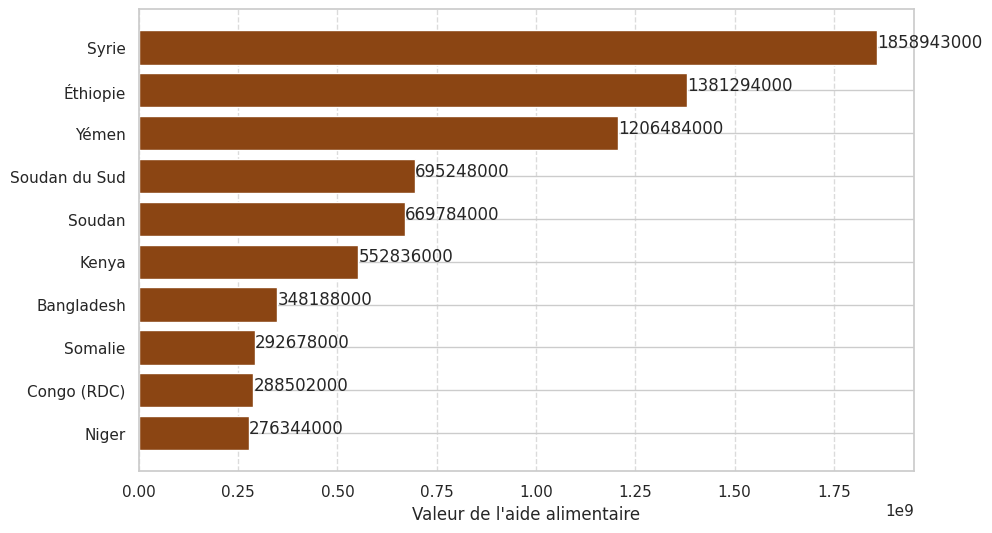

In [351]:
# Filtrer les données depuis 2013


# Dictionnaire de remplacements
remplacements = {
    'République arabe syrienne' : 'Syrie',
    'Ethiopie' : 'Ethiopie',
    'Yémen': 'Yémen',
    'Soudan du Sud': 'Soudan du Sud',
    'Soudan': 'Soudan',
    'Kenya': 'Kenya',
    'Bangladesh': 'Bangladesh',
    'Somalie': 'Somalie',
    'République démocratique du Congo': 'Congo (RDC)',
    'Niger': 'Niger',
}

# Ajouter une palette de couleurs
couleur_map = {
    'Niger': '#FF4C4C',
    'République démocratique du Congo' : '#E6E6FA',
    'Somalie': '#66B3B3',
    'Bangladesh':'#F6E42E',
    'Kenya':'#8B4513',
    'Soudan':'#FFA07A',
    'Soudan du Sud':'#98FF98',
    'Yémen':'#FFD700',
    'Ethiopie':'#F5F5DC',
    'République arabe syrienne':'#E6E6FA'
   }


# Trier les 10 données agrégées par order décroissant
pays_max_aide = aide_agregée.sort_values(by='Valeur', ascending=False).head(10)

pays_max_aide["continent"] = pays_max_aide["zone"].map(continent_map)


#remplacement des valeurs Congo (RDC) et Syrie
pays_max_aide['zone'] = pays_max_aide['zone'].replace(remplacements)
#print(f"après remplacement {pays_max_aide.head(10)}")

# Ajouter une colonne Rang*
pays_max_aide['Rang'] = range(1, len(pays_max_aide) + 1)

# Créer la liste des couleurs en fonction des labels
colors = [couleur_map.get(label, '#8B4513') for label in labels]

# Afficher en format podium
plt.figure(figsize=(10, 6))

# Créer un bar plot
plt.barh(pays_max_aide['zone'], pays_max_aide['Valeur'], color=colors)

# Annoter les valeurs sur les barres
for index, value in enumerate(pays_max_aide['Valeur']):
    plt.text(value, index, str(value))

# Titres et labels
plt.xlabel('Valeur de l\'aide alimentaire')
#plt.title('Top 10 des pays ayant bénéficié le plus d\'aide alimentaire depuis 2013')

# Affichage du podium
plt.gca().invert_yaxis()  # Pour que le premier pays soit en haut
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

DataFrame Après Pivot :
continent           Afrique          Asie
zone                                     
Bangladesh     0.000000e+00  3.481880e+08
Congo (RDC)    2.885020e+08  0.000000e+00
Kenya          5.528360e+08  0.000000e+00
Niger          2.763440e+08  0.000000e+00
Somalie        2.926780e+08  0.000000e+00
Soudan         6.697840e+08  0.000000e+00
Soudan du Sud  6.952480e+08  0.000000e+00
Syrie          0.000000e+00  1.858943e+09
Yémen          0.000000e+00  1.206484e+09
Éthiopie       1.381294e+09  0.000000e+00


/tmp/ipython-input-2439638365.py:22: FutureWarning: The provided callable <function sum at 0x7bd0615c9760> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data_aide = pays_max_aide.pivot_table(index='zone', columns='continent', values='Valeur', aggfunc=np.sum)


<Figure size 1000x600 with 0 Axes>

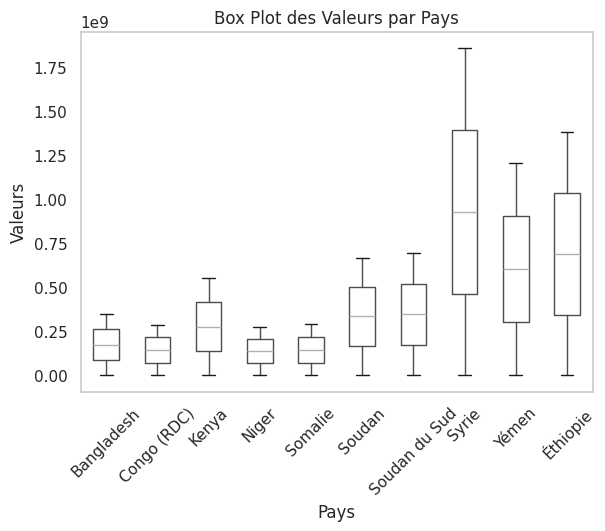

In [352]:
import matplotlib.pyplot as plt
import squarify    # pip install squarify
import pandas as pd
import numpy as np


# Trier les 10 données agrégées par order décroissant
pays_max_aide = aide_agregée.sort_values(by='Valeur', ascending=False).head(10)

pays_max_aide["continent"] = pays_max_aide["zone"].map(continent_map)


# Renommer les pays
renommages = {
    'République arabe syrienne': 'Syrie',
    'République démocratique du Congo': 'Congo (RDC)'
}
# Appliquer les changements
pays_max_aide['zone'] = pays_max_aide['zone'].replace(renommages)

# Création d'un DataFrame pivoté après avoir renommé les pays
data_aide = pays_max_aide.pivot_table(index='zone', columns='continent', values='Valeur', aggfunc=np.sum)

# Remplir NaN par 0 pour éviter les erreurs lors de la somme
data_aide = data_aide.fillna(0)

# Affichage des pays renommés dans le DataFrame pivoté
print("DataFrame Après Pivot :", data_aide, sep="\n")

# Restructurer les données pour le Box Plot
box_data = pd.melt(data_aide.reset_index(), id_vars=['zone'], value_vars=data_aide.columns, var_name='continent', value_name='values')

# Box Plot
plt.figure(figsize=(10, 6))
box_data.boxplot(by='zone', column='values', grid=False)
plt.title('Box Plot des Valeurs par Pays')
plt.suptitle('')
plt.xlabel('Pays')
plt.ylabel('Valeurs')
plt.xticks(rotation=45)
plt.show()

DataFrame Après Pivot :
continent                              Afrique          Asie
zone                                                        
Bangladesh                        0.000000e+00  3.481880e+08
Kenya                             5.528360e+08  0.000000e+00
Niger                             2.763440e+08  0.000000e+00
République arabe syrienne         0.000000e+00  1.858943e+09
République démocratique du Congo  2.885020e+08  0.000000e+00
Somalie                           2.926780e+08  0.000000e+00
Soudan                            6.697840e+08  0.000000e+00
Soudan du Sud                     6.952480e+08  0.000000e+00
Yémen                             0.000000e+00  1.206484e+09
Éthiopie                          1.381294e+09  0.000000e+00


/tmp/ipython-input-2764684037.py:10: FutureWarning: The provided callable <function sum at 0x7bd0615c9760> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data_aide = pays_max_aide.pivot_table(index='zone', columns='continent', values='Valeur', aggfunc=np.sum)


<Figure size 1000x600 with 0 Axes>

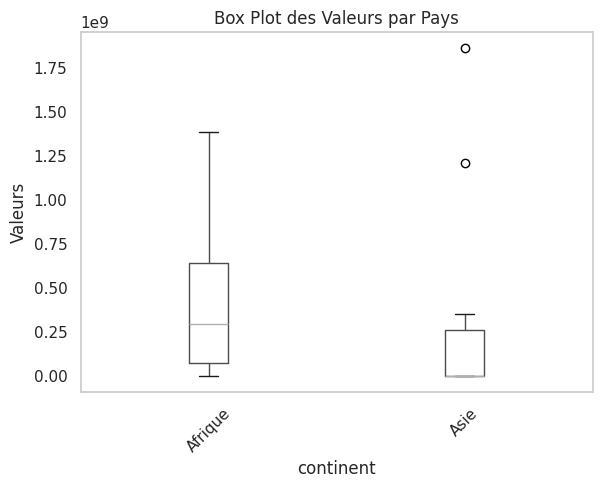

In [353]:
import pandas as pd
import numpy as np

# Trier les 10 données agrégées par order décroissant
pays_max_aide = aide_agregée.sort_values(by='Valeur', ascending=False).head(10)

pays_max_aide["continent"] = pays_max_aide["zone"].map(continent_map)

# Création d'un DataFrame pivoté après avoir renommé les pays
data_aide = pays_max_aide.pivot_table(index='zone', columns='continent', values='Valeur', aggfunc=np.sum)

# Remplir NaN par 0 pour éviter les erreurs lors de la somme
data_aide = data_aide.fillna(0)

# Affichage des pays renommés dans le DataFrame pivoté
print("DataFrame Après Pivot :", data_aide, sep="\n")

# Restructurer les données pour le Box Plot
box_data = pd.melt(data_aide.reset_index(), id_vars=['zone'], value_vars=data_aide.columns, var_name='continent', value_name='values')

# Box Plot
plt.figure(figsize=(10, 6))
box_data.boxplot(by='continent', column='values', grid=False)
plt.title('Box Plot des Valeurs par Pays')
plt.suptitle('')
plt.xlabel('continent')
plt.ylabel('Valeurs')
plt.xticks(rotation=45)
plt.show()

#3.8 Evolution des 5 pays qui ont le plus bénéficié de l'aide alimentaire entre 2013 et 2016

In [354]:
#création d'une liste contenant les 5 pays qui ont le plus bénéficié de l'aide alimentaire
ma_liste = [
    'République arabe syrienne',
    'Éthiopie',
    'Yémen',
    'Soudan du Sud',
    'Soudan',
]
print (ma_liste)

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [355]:
#on filtre sur le dataframe avec notre liste
filtre_loc_aide = aide_alimentaire[aide_alimentaire['zone'].isin(ma_liste)]
print(filtre_loc_aide.head(5))

         zone  Année              Produit     Valeur
354  Éthiopie   2013  Autres non-céréales     170000
355  Éthiopie   2014  Autres non-céréales     466000
356  Éthiopie   2015  Autres non-céréales     244000
357  Éthiopie   2013         Blé et Farin  181066000
358  Éthiopie   2014         Blé et Farin  178646000


   Année                       zone     Valeur
0   2013  République arabe syrienne  563566000
1   2013                     Soudan  330230000
2   2013              Soudan du Sud  196330000
3   2013                      Yémen  264764000
4   2013                   Éthiopie  591404000


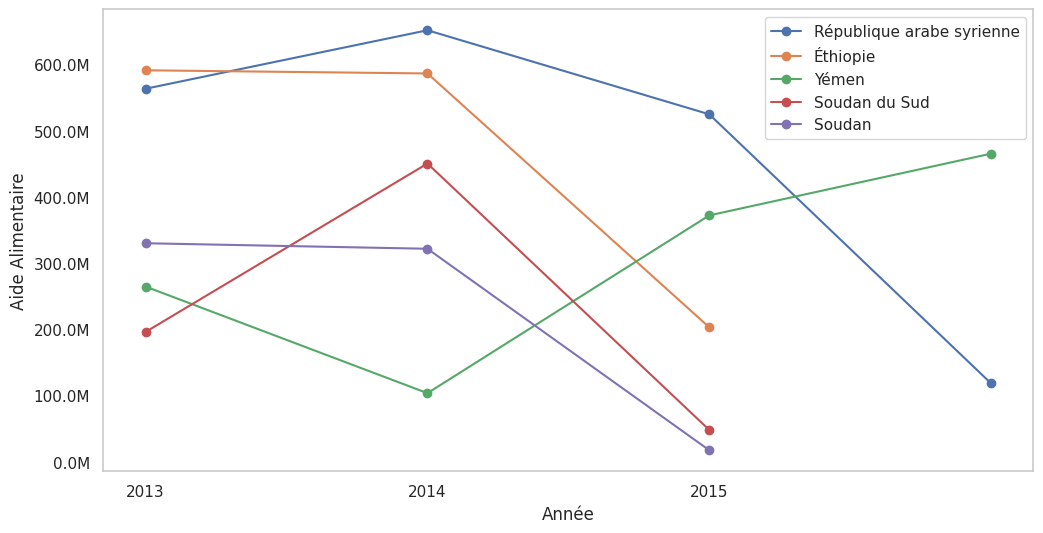

In [356]:
#afficher les pays avec l'aide alimentaire par année
# Agréger les données par Année et zone
aide_agregée = filtre_loc_aide.groupby(['Année', 'zone'])['Valeur'].sum().reset_index()
print (aide_agregée.head(5))
# Tracer la courbe d'évolution
plt.figure(figsize=(12, 6))

for pays in ma_liste:
    data_pays = aide_agregée[aide_agregée['zone'] == pays]
    plt.plot(data_pays['Année'], data_pays['Valeur'], marker='o', label=pays)

# Personnaliser le graphique
from matplotlib.ticker import FuncFormatter

def millions(x, pos):
    return '%1.1fM' % (x * 1e-6)


plt.xlabel('Année')
plt.ylabel('Aide Alimentaire')
#plt.title('Évolution de l\'Aide Alimentaire pour les 5 Pays ayant reçu le plus d\'aide alimentaire')
#plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.legend()
plt.grid()
plt.xticks(data_pays['Année'].unique())  # Pour afficher toutes les années
plt.show()

#3.9 Pays avec le moins de disponibilité par habitant

In [357]:
#calcul de la disponibilité en kcal par personne par jour par pays

print (dispo_alimentaire.columns)


#filtre par groupby des pays
dispo_par_pays = dispo_alimentaire.groupby(['Zone'])['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()
dispo_par_pays = dispo_par_pays.sort_values(by ='Disponibilité alimentaire (Kcal/personne/jour)', ascending=True)


Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock'],
      dtype='object')


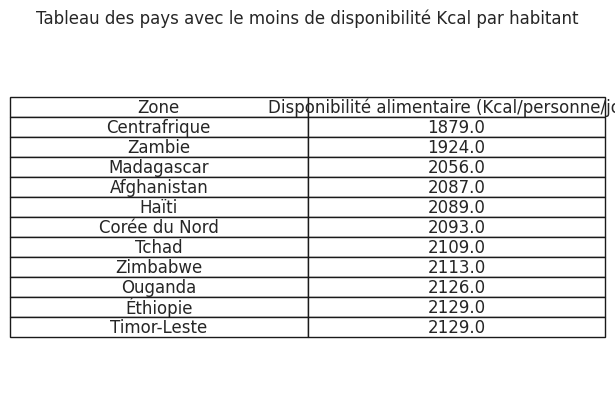

In [358]:
#affichage des 10 pays qui ont le moins de dispo alimentaire par personne en Tableau
dispo_par_pays= dispo_par_pays.head(11)

# Renommer les pays
renommages = {
    'République centrafricaine': 'Centrafrique',
    'République populaire démocratique de Corée': 'Corée du Nord'
}
# Appliquer les changements
dispo_par_pays['Zone'] = dispo_par_pays['Zone'].replace(renommages)

fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=dispo_par_pays.values, colLabels=dispo_par_pays.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.title('Tableau des pays avec le moins de disponibilité Kcal par habitant')
plt.show()

In [359]:
#On calcule le taux de sous nutrition par pays avant de merger

#afficher le dataset avant calcul %
print ("df_jointure_2017 avant calcul % : ")
print(df_jointure_2017.head(5))

#Calculer un taux par ligne (ex. : taux de sous-nutrition par pays)
df_jointure_2017['sous_nutrition_pct'] = df_jointure_2017.apply(lambda row: row['sous-nutrition'] / row['population']*100, axis=1)

df_jointure_2017 avant calcul % : 
             Zone  Année_x  population  Année_y  sous-nutrition
0     Afghanistan     2017  36296113.0     2017      11100000.0
1  Afrique du Sud     2017  57009756.0     2017       3300000.0
2         Albanie     2017   2884169.0     2017        100000.0
3         Algérie     2017  41389189.0     2017       1200000.0
4       Allemagne     2017  82658409.0     2017             0.0


           pays  dispo_kcal
0  Centrafrique      1879.0
1        Zambie      1924.0
2    Madagascar      2056.0
3   Afghanistan      2087.0
4         Haïti      2089.0


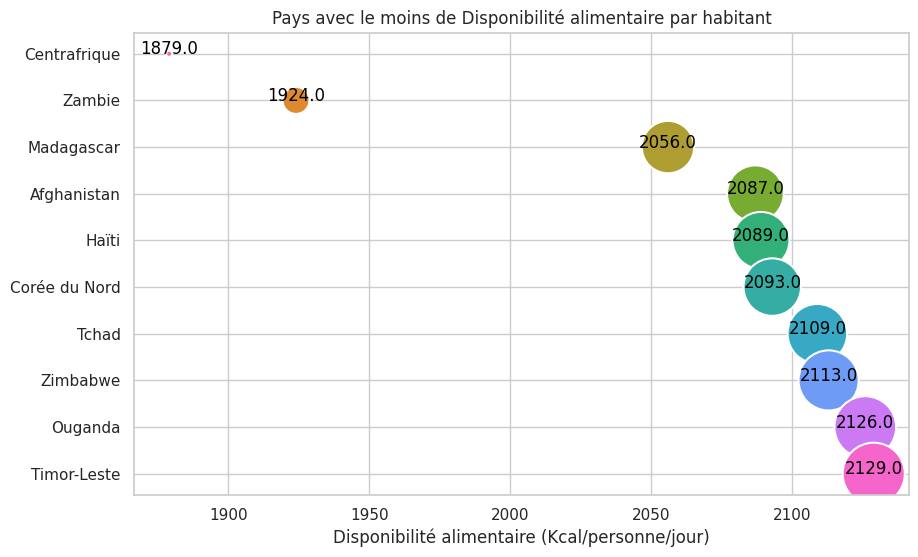

In [360]:
# libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Supposons que continent_map est déjà défini et jointureDispoAlimentaire_Popu2017 est un DataFrame existant
# ajout de la colonne Continent dans dispo_par_pays (jointure population)
jointureDispoAlimentaire_Popu2017['continent'] = jointureDispoAlimentaire_Popu2017['Zone'].map(continent_map)

# Filtrer par pays et disponibilité alimentaire Kcal
jointureDispoAlimentaire_Popu2017 = jointureDispoAlimentaire_Popu2017.groupby(['Zone'])['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()

# Trier par ordre croissant
jointureDispoAlimentaire_Popu2017 = jointureDispoAlimentaire_Popu2017.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=True)


# Renommer les pays
renommages = {
    'République centrafricaine': 'Centrafrique',
    'République populaire démocratique de Corée': 'Corée du Nord'
}
# Appliquer les changements
jointureDispoAlimentaire_Popu2017['Zone'] = jointureDispoAlimentaire_Popu2017['Zone'].replace(renommages)

# Ne garder que les 10 premiers de la liste
top10 = jointureDispoAlimentaire_Popu2017.head(10)

# Exemple de données
data = {
    'pays': top10['Zone'].tolist(),   # Top10 pays
    'dispo_kcal': top10['Disponibilité alimentaire (Kcal/personne/jour)'].tolist()   # Disponibilité alimentaire Kcal
}

food_data = pd.DataFrame(data)

# Affichage pour vérification
print(food_data.head(5))

# Création d'une carte des couleurs pour les pays
colors = sns.color_palette("husl", len(food_data))

# Scatterplot pour la disponibilité alimentaire
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=food_data,
    x="dispo_kcal",
    y="pays",
    size="dispo_kcal",  # Taille des bulles en fonction de la disponibilité alimentaire
    legend=False,
    sizes=(20, 2000),
    palette=colors,  # Appliquer la palette de couleurs
    hue='pays'  # Changer la couleur des points en fonction des pays
)


# Ajout des étiquettes de pays
for i in range(food_data.shape[0]):
    plt.text(
        food_data.dispo_kcal[i],
        i + 0.1,  # Positionnement vertical par rapport à l'index
        f"{food_data.dispo_kcal[i]}",
        horizontalalignment='center',
        verticalalignment='bottom',
        fontsize=12,
        color='black'
    )

# Ajout d'une grille
plt.grid(True)



# Ajout des labels
plt.title('Pays avec le moins de Disponibilité alimentaire par habitant')
plt.xlabel('Disponibilité alimentaire (Kcal/personne/jour)')
plt.ylabel('')

# Affichage du graphique
plt.show()

#3.10 Pays avec le plus de disponibilité par habitant

In [361]:
#calcul de la disponibilité en kcal par personne par jour par pays
df_jointureDispoAlimentaire_Popu2017 = jointureDispoAlimentaire_Popu2017.copy()

print (df_jointureDispoAlimentaire_Popu2017.columns)


#filtre par groupby des pays
dispo_par_pays2 = df_jointureDispoAlimentaire_Popu2017.groupby(['Zone'])['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()
dispo_par_pays2 = dispo_par_pays2.sort_values(by ='Disponibilité alimentaire (Kcal/personne/jour)', ascending=False)

Index(['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)'], dtype='object')


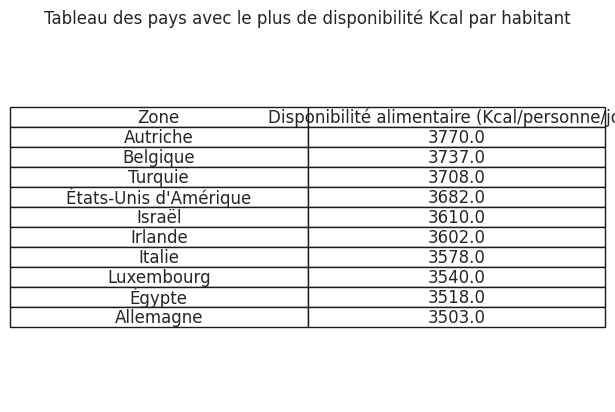

In [362]:
#affichage des 10 pays qui ont le moins de dispo alimentaire par personne en Tableau
dispo_par_pays2= dispo_par_pays2.head(10)


fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=dispo_par_pays2.values, colLabels=dispo_par_pays2.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.title('Tableau des pays avec le plus de disponibilité Kcal par habitant')
plt.show()

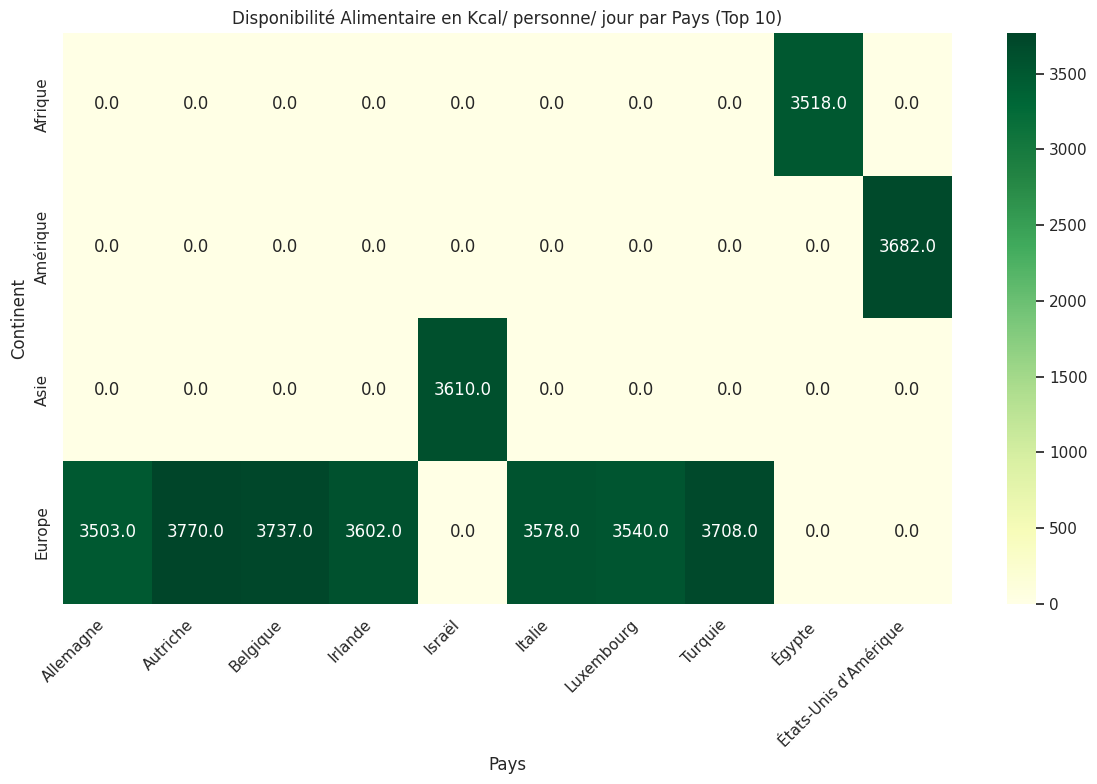

In [363]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filtre par groupby des pays
dispo_par_pays2 = df_jointureDispoAlimentaire_Popu2017.groupby(['Zone'])['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()

# Ajouter la colonne Continent
dispo_par_pays2['continent'] = dispo_par_pays2['Zone'].map(continent_map)

# Obtenir les 10 pays avec la plus forte disponibilité alimentaire
top10_pays = dispo_par_pays2.nlargest(10, 'Disponibilité alimentaire (Kcal/personne/jour)')

# Pivot pour obtenir la structure analytique
heatmap_data = top10_pays.pivot_table(index='continent', columns='Zone', values='Disponibilité alimentaire (Kcal/personne/jour)')

# Remplacer les valeurs NaN par 0 ou une autre valeur appropriée
heatmap_data = heatmap_data.fillna(0)

# Création de la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGn', annot=True, fmt='.1f')
plt.title('Disponibilité Alimentaire en Kcal/ personne/ jour par Pays (Top 10)')
plt.xlabel('Pays')
plt.ylabel('Continent')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()  # Pour ajuster l'affichage
plt.show()

#3.11 Exemple de la Thailande pour le Manioc

In [364]:
#création d'un dataframe avec uniquement la thailande

# Assurez-vous que vous avez déjà créé 'df_sous_nutrition_2017'

# Charger les données avec un encodage approprié
df_sous_nutrition_2017 = pd.read_csv('sous_nutrition.csv', encoding='utf-8')

# Vérifiez les noms de colonnes disponibles
print("Colonnes disponibles : ", df_sous_nutrition_2017.columns)


# Utiliser groupby pour totaliser la sous-nutrition par pays
totals = df_sous_nutrition_2017.groupby('Zone')['Valeur'].sum()

# Vérifiez si la Thaïlande est dans les données
if 'Thaïlande' in totals.index:
    sous_nutrition_thailande = totals['Thaïlande']
    print(f"Sous-nutrition en Thaïlande : {sous_nutrition_thailande}")
else:
    print("Aucune donnée trouvée pour la Thaïlande.")

# Renommer la colonne si nécessaire
df_sous_nutrition_2017.rename(columns={'Valeur': 'sous_nutrition'}, inplace=True)

# Créer une table pivot pour totaliser la sous-nutrition par pays
table_pivot = df_sous_nutrition_2017.pivot_table(
    index='Zone',
    values='sous_nutrition',  # Nom sans tréma
    aggfunc='sum'
)



# Afficher les données résultantes
print(table_pivot.head())

# Extraire la valeur spécifique pour la Thaïlande
sous_nutrition_thailande = table_pivot.at['Thaïlande', 'sous_nutrition']
print(f"Sous-nutrition en Thaïlande : {sous_nutrition_thailande}")
print(type(sous_nutrition_thailande))

# Remplacez les points dans la chaîne
sous_nutrition_thailande_cleaned = sous_nutrition_thailande.replace('.', '')

# Convertir la chaîne nettoyée en float (si nécessaire)
sous_nutrition_thailande_float = float(sous_nutrition_thailande_cleaned)

# Afficher la valeur après le nettoyage
print(f"Sous-nutrition (après nettoyage) en Thaïlande : {sous_nutrition_thailande_float}")



Colonnes disponibles :  Index(['Zone', 'Année', 'Valeur'], dtype='object')
Sous-nutrition en Thaïlande : 6.265.966.26.5
                      sous_nutrition
Zone                                
Afghanistan     8.68.88.99.710.511.1
Afrique du Sud      2.22.52.833.13.3
Albanie           0.10.10.10.10.10.1
Algérie           1.31.31.31.31.31.2
Allemagne                          0
Sous-nutrition en Thaïlande : 6.265.966.26.5
<class 'str'>
Sous-nutrition (après nettoyage) en Thaïlande : 6265966265.0


In [365]:
#Calcul de la sous nutrition en Thaïlande
# Calcul de la sous-nutrition en Thaïlande

# Calcul de la disponibilité en kcal par personne par jour par pays
PopuThailande2 = df_population_2017[df_population_2017['Zone'] == 'Thaïlande']
print(PopuThailande2.head(5))

total_popu_thailande = PopuThailande2['population'].sum()
print(f"Calcul de la population de la Thaïlande : {format_americain(total_popu_thailande)}")

# Vérifiez si les valeurs sont numériques
print("Sous-nutrition en Thaïlande : ", sous_nutrition_thailande)
print("Total population thaïlandaise : ", total_popu_thailande)

# Assurez-vous que les valeurs sont des floats
try:
    # Convertir sous_nutrition_thailande en float après nettoyage
    sous_nutrition_thailande_float = float(sous_nutrition_thailande.replace('.', ''))

    # Convertir total_popu_thailande en float
    total_popu_thailande = float(total_popu_thailande)

    # Calcul de la part en % de la Thaïlande dans la sous-nutrition mondiale de 2013 à 2016
    partThailandesousnutritionmondiale = round(sous_nutrition_thailande_float / total_popu_thailande * 100, 2)

    print(f"Total du nombre de personnes en sous-nutrition rapporté à sa population : \n {format_americain(partThailandesousnutritionmondiale)}")
except ValueError as e:
    print(f"Erreur de conversion : {e}")


           Zone  Année  population
1312  Thaïlande   2017  69209810.0
Calcul de la population de la Thaïlande : 69,209,810.00
Sous-nutrition en Thaïlande :  6.265.966.26.5
Total population thaïlandaise :  69209810.0
Total du nombre de personnes en sous-nutrition rapporté à sa population : 
 9,053.58


In [366]:
# On calcule la proportion exportée en fonction de la production
# Affiche les valeurs uniques pour vérifier l'existence des éléments

# Charger les données avec un encodage approprié
df_dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv', encoding='utf-8')

# Vérifiez les noms de colonnes disponibles
print("Colonnes disponibles : ", df_dispo_alimentaire.columns)



# Nettoyer les colonnes en retirant les espaces
df_dispo_alimentaire['Zone'] = df_dispo_alimentaire['Zone'].str.strip()
df_dispo_alimentaire['Produit'] = df_dispo_alimentaire['Produit'].str.strip()

print(df_dispo_alimentaire['Zone'].unique())
print(df_dispo_alimentaire['Produit'].unique())

# Filtrer à nouveau
filtre_manioc_thailande = dispo_alimentaire[
    (df_dispo_alimentaire['Zone'] == 'Thaïlande') &
    (df_dispo_alimentaire['Produit'] == 'Manioc')
]

# Afficher le résultat du filtre
print(filtre_manioc_thailande.head())

# Vérifiez si le filtre a retourné des résultats
if not filtre_manioc_thailande.empty:
    CalculPartExportations = round(
        filtre_manioc_thailande['Exportations - Quantité'].values[0] / filtre_manioc_thailande['Production'].values[0] * 100,
        2
    )
    print(f"Calcul de la part des exportations de manioc en Thaïlande par rapport à sa production : {CalculPartExportations}%")
else:
    print("Aucune donnée trouvée pour le manioc en Thaïlande.")

# Filtre pour la production mondiale de manioc
filtre_prodmondialemanioc = dispo_alimentaire[
    (dispo_alimentaire['Produit'] == 'Manioc') &
    (dispo_alimentaire['Production'] > 0)
]

# Vérifiez si le filtre mondial a retourné des résultats
if not filtre_manioc_thailande.empty and not filtre_prodmondialemanioc.empty:
    calculProdManioc = round(
        filtre_manioc_thailande['Production'].sum() / filtre_prodmondialemanioc['Production'].sum() * 100,
        2
    )
    print(f"Calcul de la part de production mondiale de manioc par la Thaïlande : {calculProdManioc}%")
else:
    print("Aucune donnée de production mondiale de manioc trouvée.")

# On calcule la proportion exportée en fonction de sa disponibilité intérieure
if not filtre_manioc_thailande.empty:
    dispointManioc = (
        filtre_manioc_thailande['Production'].sum() +
        filtre_manioc_thailande['Importations - Quantité'].sum() -
        filtre_manioc_thailande['Exportations - Quantité'].sum() +
        filtre_manioc_thailande['Variation de stock'].sum()
    )

    print(f"Disponibilité intérieure de manioc : {dispointManioc}")

    CalculPartDispoInteieure = round(dispointManioc / filtre_manioc_thailande['Production'].values[0] * 100, 2)
    print(f"Calcul de la part des exportations de manioc en Thaïlande par rapport à sa disponibilité intérieure : {CalculPartDispoInteieure}%")
else:
    print("Aucune donnée trouvée pour le calcul de la disponibilité intérieure de manioc.")


Colonnes disponibles :  Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock'],
      dtype='object')
['Afghanistan' 'Afrique du Sud' 'Albanie' 'Algérie' 'Allemagne' 'Angola'
 'Antigua-et-Barbuda' 'Arabie saoudite' 'Argentine' 'Arménie' 'Australie'
 'Autriche' 'Azerbaïdjan' 'Bahamas' 'Bangladesh' 'Barbade' 'Belgique'
 'Belize' 'Bermudes' 'Bolivie (État plurinational de)'
 'Bosnie-Herzégovine' 'Botswana' 'Brunéi Darussalam' 'Brésil' 'Bulgarie'
 'Burkina Faso' 'Bélarus' 'Bénin' 'Cabo Verde' 'Cambodge' 'Cameroun'
 'Ca

#  Graphiques sur le MANIOC

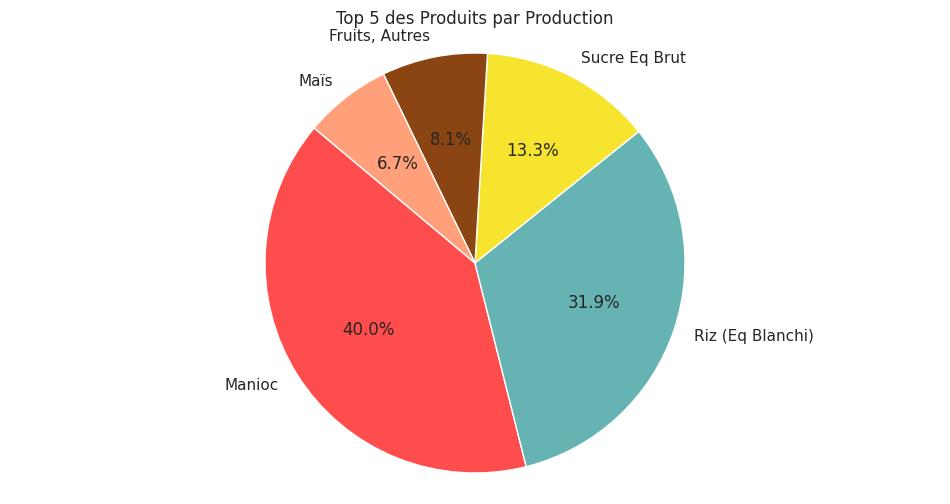

In [367]:
import pandas as pd
import matplotlib.pyplot as plt

# Hypothétiques données : même calcul qu'au-dessus en rajoutant la proportion nourriture et alimentation animale

# Filtrer les produits par zone et conditions d'exportation
filtre_Produits_thailande = df_dispo_alimentaire[
    (df_dispo_alimentaire['Zone'] == 'Thaïlande') &
    (df_dispo_alimentaire['Exportations - Quantité'] > 0) &
    (df_dispo_alimentaire['Production'] > 0)
]

#print (filtre_Produits_thailande)

# Initialiser un dictionnaire pour stocker les résultats
results = {
    'Produit': [],
    'Part Exportations (%)': [],
    'Part Nourriture (%)': [],
    'Part Alimentation Animale (%)': []
}

# Boucle pour calculer les parts pour chaque produit
for index, row in filtre_Produits_thailande.iterrows():
    produit = row['Produit']
    exportations = row['Exportations - Quantité']
    production = row['Production']
    nourriture = row['Nourriture']
    alimentsAnimaux = row['Aliments pour animaux']
    # Calcul des parts
    CalculPartExportations = round((exportations / production) * 100, 2)
    CalculPartNourriture = round((nourriture / production) * 100, 2)
    CalculPartAlimentAnimaux = round((alimentsAnimaux / production) * 100, 2)
    # Ajouter les résultats au dictionnaire
    results['Produit'].append(produit)
    results['Part Exportations (%)'].append(CalculPartExportations)
    results['Part Nourriture (%)'].append(CalculPartNourriture)
    results['Part Alimentation Animale (%)'].append(CalculPartAlimentAnimaux)

# Créer un DataFrame à partir du dictionnaire
result_df = pd.DataFrame(results)

# Calculer les trois Top 5
#top5_exportations = filtre_Produits_thailande.nlargest(5, 'Exportations - Quantité')
#"top5_nourriture = filtre_Produits_thailande.nlargest(5, 'Nourriture')
#top5_aliment_animaux = filtre_Produits_thailande.nlargest(5, 'Aliments pour animaux')
top5_production= filtre_Produits_thailande.nlargest(5, 'Production')

# Couleurs pour le premier camembert
colors1 = ['#FF4C4C', '#66B3B3','#F6E42E', '#8B4513','#FFA07A','#98FF98','#FFD700','#F5F5DC']

# Visualiser les Top 5 avec Matplotlib
fig, ax = plt.subplots(figsize=(12, 6))  # Un seul graphique

# Tracer le camembert pour le Top 5 des productions
ax.pie(top5_production['Production'], labels=top5_production['Produit'],
       autopct='%1.1f%%', colors=colors1, startangle=140)
ax.set_title('Top 5 des Produits par Production')

# Afficher le graphique
plt.axis('equal')  # Pour un camembert circulaire
plt.show()

# Etude du Manioc en Thailande


In [368]:
# Filtrer les données pour toutes les lignes où le produit est "manioc"
print (filtre_manioc_thailande) # il n'y a pas toutes les lignes

# Charger les données avec un encodage approprié
df_dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv', encoding='utf-8')

data = df_dispo_alimentaire.loc[
    (df_dispo_alimentaire['Produit'] == 'Manioc')
]

print (data.head(5))

            Zone Produit   Origine  Aliments pour animaux  \
13809  Thaïlande  Manioc  vegetale           1.800000e+09   

       Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
13809         2.081000e+09                                            40.0   

       Disponibilité alimentaire en quantité (kg/personne/an)  \
13809                                               13.0        

       Disponibilité de matière grasse en quantité (g/personne/jour)  \
13809                                               0.05               

       Disponibilité de protéines en quantité (g/personne/jour)  \
13809                                               0.14          

       Disponibilité intérieure  Exportations - Quantité  \
13809              6.264000e+09             2.521400e+10   

       Importations - Quantité   Nourriture        Pertes    Production  \
13809             1.250000e+09  871000000.0  1.511000e+09  3.022800e+10   

       Semences  Traitement  Variatio

In [369]:
# Filtrer les données pour 'Manioc' et 'Thaïlande'
filtered_data = df_dispo_alimentaire.loc[
    (df_dispo_alimentaire['Produit'] == 'Manioc')
]

# Remplir NaN : premièrement, remplacer les NaN par la moyenne pour les colonnes numériques
for col in filtered_data.select_dtypes(include=[float, int]).columns:
    filtered_data[col] = filtered_data[col].fillna(filtered_data[col].mean())

# Vérifier le DataFrame nettoyé
print("Données après nettoyage :")
print(filtered_data)




Données après nettoyage :
                        Zone Produit   Origine  Aliments pour animaux  \
110           Afrique du Sud  Manioc  vegetale                 870.56   
203                  Albanie  Manioc  vegetale                 870.56   
295                  Algérie  Manioc  vegetale                 870.56   
390                Allemagne  Manioc  vegetale                   1.00   
475                   Angola  Manioc  vegetale                8880.00   
...                      ...     ...       ...                    ...   
15108                 Égypte  Manioc  vegetale                   0.00   
15201    Émirats arabes unis  Manioc  vegetale                 870.56   
15294               Équateur  Manioc  vegetale                   0.00   
15390  États-Unis d'Amérique  Manioc  vegetale                 288.00   
15567           Îles Salomon  Manioc  vegetale                   0.00   

       Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
110              57

/tmp/ipython-input-24498989.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data[col] = filtered_data[col].fillna(filtered_data[col].mean())


/usr/local/lib/python3.12/dist-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


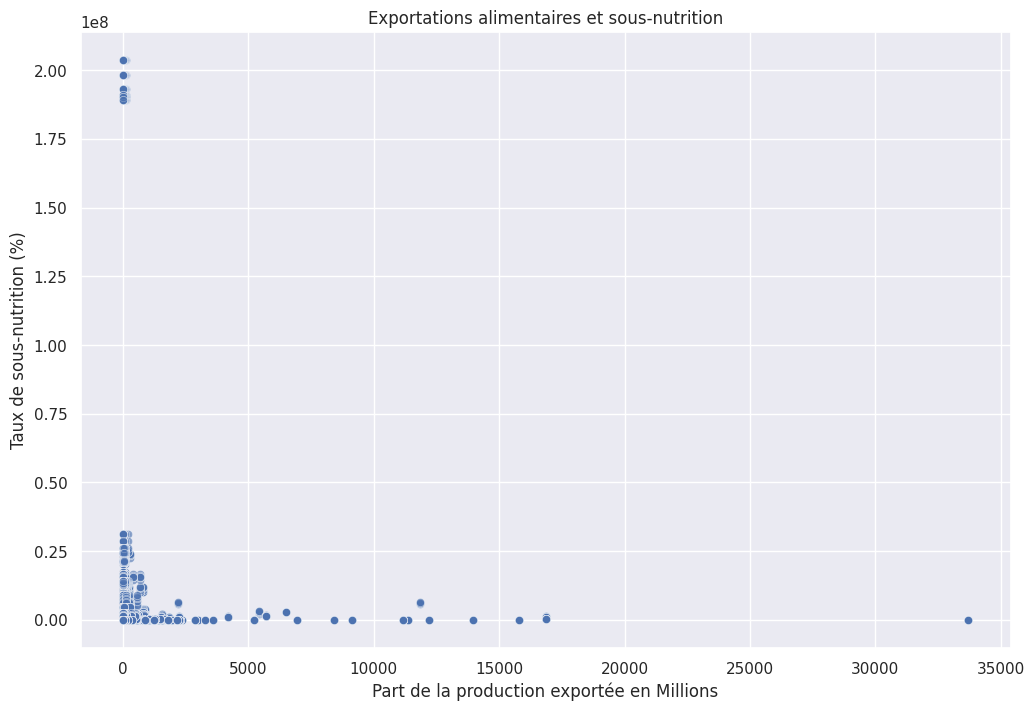

In [370]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. Fusion des datasets
# =========================
data_export = pd.merge(
    dispo_alimentaire,
    sous_nutrition,
    on='Zone',
    how='inner'
)

# Nettoyage minimal
data_export = data_export.dropna(subset=['Production', 'sous-nutrition', 'Exportations - Quantité'])

# =========================
# 2. Calcul de la part exportée
# =========================
data_export['part_export'] = (
    data_export['Exportations - Quantité'] /
    data_export['Production']
) * 100

# =========================
# 3. Agrégation Thaïlande (sécurisée)
# =========================
thai = (
    data_export[data_export['Zone'] == 'Thaïlande']
    .groupby('Zone', as_index=False)
    .agg({
        'part_export': 'mean',
        'sous-nutrition': 'mean'
    })
)

# =========================
# 4. Scatterplot
# =========================
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=data_export,
    x='part_export',
    y='sous-nutrition',
    alpha=0.6
)

# Mise en évidence de la Thaïlande (si présente)
if not thai.empty:
    plt.scatter(
        thai['part_export'].iloc[0],
        thai['sous-nutrition'].iloc[0],
        color='red',
        s=200
    )
    plt.text(
        thai['part_export'].iloc[0] + 1,
        thai['sous-nutrition'].iloc[0],
        "Thaïlande",
        fontsize=12,
        weight='bold'
    )

# Titres et labels
plt.xlabel("Part de la production exportée en Millions")
plt.ylabel("Taux de sous-nutrition (%)")
plt.title("Exportations alimentaires et sous-nutrition", loc='center')
plt.grid(True)

plt.show()

#Etape 6 Ajouter en dessous toutes les analyses complémentaires

# Relation taux de sous-nutrition et production

Coefficient de Pearson (production vs sous-nutrition) : 0.094


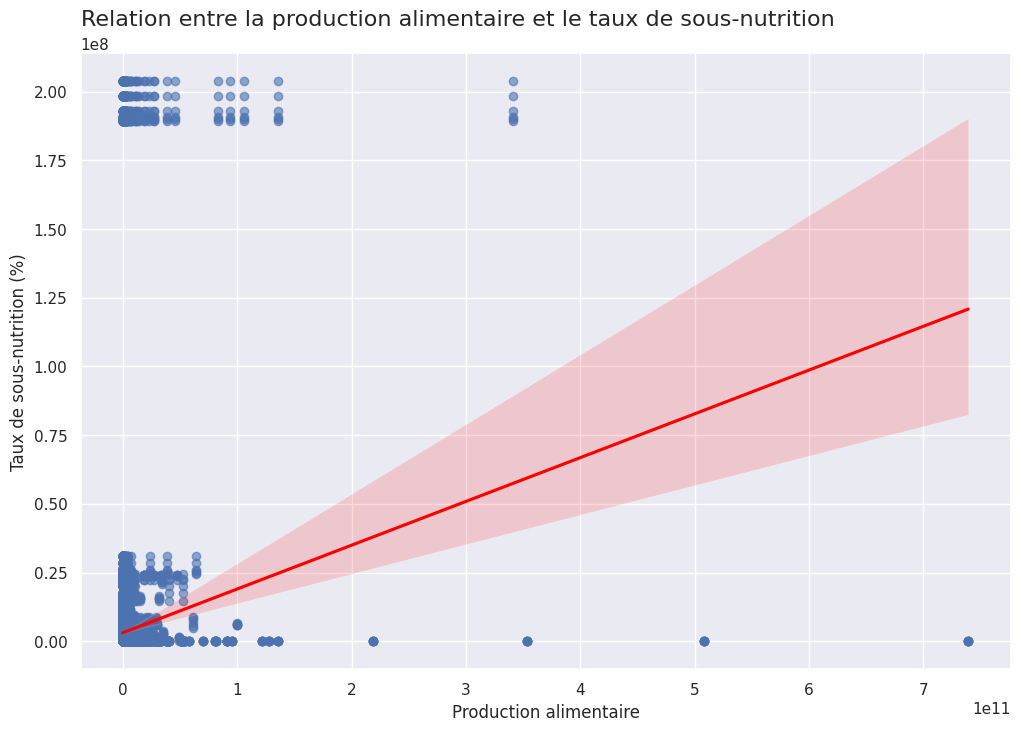

In [371]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Fusion des datasets
# =========================
data_prod = pd.merge(
    dispo_alimentaire,
    sous_nutrition,
    on='Zone',
    how='inner'
)

data_prod['Continent'] = data_prod['Zone'].map(continent_map)


# Nettoyage minimal (au cas où)
data_prod = data_prod.dropna(subset=['Production', 'sous-nutrition'])

# =========================
# 2. Dataset pour Pearson
# =========================
df = pd.DataFrame({
    'zone': data_prod['Zone'],
    'production': data_prod['Production'],
    'sous_nutrition': data_prod['sous-nutrition'],
    'continent': data_prod['Continent'],
    'origine': data_prod['Origine']
})

# =========================
# 3. Calcul du coefficient de Pearson
# =========================
r = df['production'].corr(df['sous_nutrition'], method='pearson')
print(f"Coefficient de Pearson (production vs sous-nutrition) : {r:.3f}")

# =========================
# 4. Scatterplot + droite de régression
# =========================
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 8))

sns.regplot(
    data=df,
    x="production",
    y="sous_nutrition",
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title(
    "Relation entre la production alimentaire et le taux de sous-nutrition",
    fontsize=16,
    loc='left',
    pad=20
)

plt.xlabel("Production alimentaire")
plt.ylabel("Taux de sous-nutrition (%)")
plt.grid(True)

plt.show()

# Heatmap des pays ayant la plus faible disponibilité en Kcal

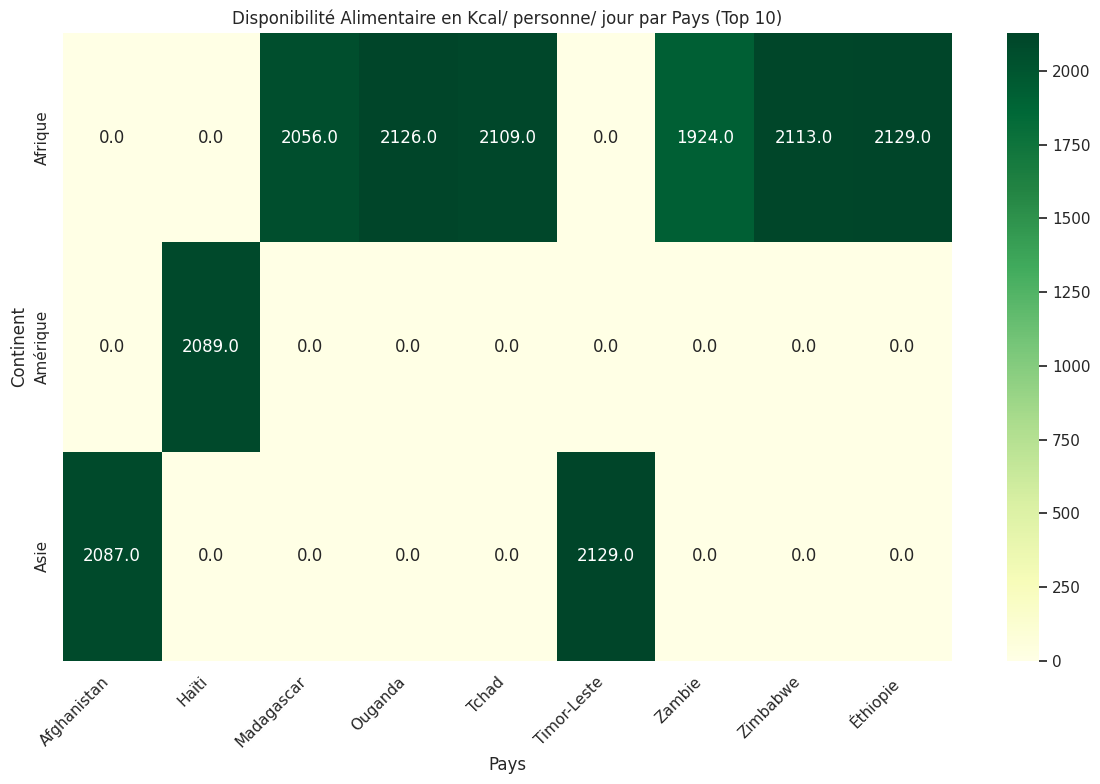

In [372]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Obtenir les 10 pays avec la plus forte disponibilité alimentaire
top10_pays = dispo_par_pays.nlargest(10, 'Disponibilité alimentaire (Kcal/personne/jour)')

top10_pays['continent'] = top10_pays['Zone'].map(continent_map)

# Pivot pour obtenir la structure analytique
heatmap_data = top10_pays.pivot_table(index='continent', columns='Zone', values='Disponibilité alimentaire (Kcal/personne/jour)')

# Remplacer les valeurs NaN par 0 ou une autre valeur appropriée
heatmap_data = heatmap_data.fillna(0)

# Création de la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGn', annot=True, fmt='.1f')
plt.title('Disponibilité Alimentaire en Kcal/ personne/ jour par Pays (Top 10)')
plt.xlabel('Pays')
plt.ylabel('Continent')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()  # Pour ajuster l'affichage
plt.show()

#Répartition  de la sous nutrition par Continent

             Zone  Année_x  population  Année_y  sous-nutrition  \
0     Afghanistan     2017  36296113.0     2017      11100000.0   
1  Afrique du Sud     2017  57009756.0     2017       3300000.0   
2         Albanie     2017   2884169.0     2017        100000.0   
3         Algérie     2017  41389189.0     2017       1200000.0   
4       Allemagne     2017  82658409.0     2017             0.0   

   sous_nutrition_pct  
0           30.581787  
1            5.788483  
2            3.467203  
3            2.899308  
4            0.000000  
             Zone  Année_x  population  Année_y  sous-nutrition  \
0     Afghanistan     2017  36296113.0     2017      11100000.0   
1  Afrique du Sud     2017  57009756.0     2017       3300000.0   
2         Albanie     2017   2884169.0     2017        100000.0   
3         Algérie     2017  41389189.0     2017       1200000.0   
4       Allemagne     2017  82658409.0     2017             0.0   

   sous_nutrition_pct Continent  
0           30.5

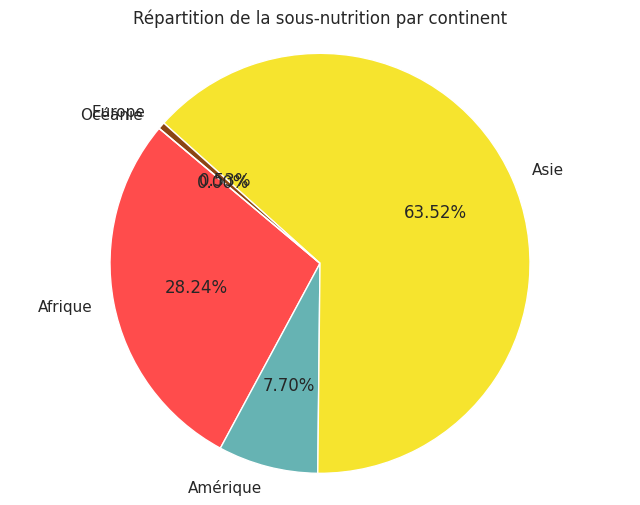

In [373]:
# Vérification de la production et de la disponibilité alimentaire
print(df_jointure_2017.head(5))
df_jointure_2017['Continent'] = df_jointure_2017['Zone'].map(continent_map)


import matplotlib.pyplot as plt

# Vérification rapide
print(df_jointure_2017.head(5))

# Agrégation par continent
data_pie = (
    df_jointure_2017
    .groupby('Continent')['sous-nutrition']
    .sum()
    .dropna()
)

# Labels et tailles
labels = data_pie.index.tolist()
sizes = data_pie.values.tolist()

# Couleurs (doivent être au moins aussi nombreuses que les continents)
colors = ['#FF4C4C', '#66B3B3', '#F6E42E', '#8B4513', '#9370DB', '#20B2AA']

# Vérification de cohérence
if len(labels) == len(sizes) and len(sizes) > 0:
    plt.figure(figsize=(8, 6))
    plt.pie(
        sizes,
        labels=labels,
        colors=colors[:len(labels)],
        autopct='%1.2f%%',
        startangle=140
    )
    plt.axis('equal')
    plt.title('Répartition de la sous-nutrition par continent')
    plt.show()

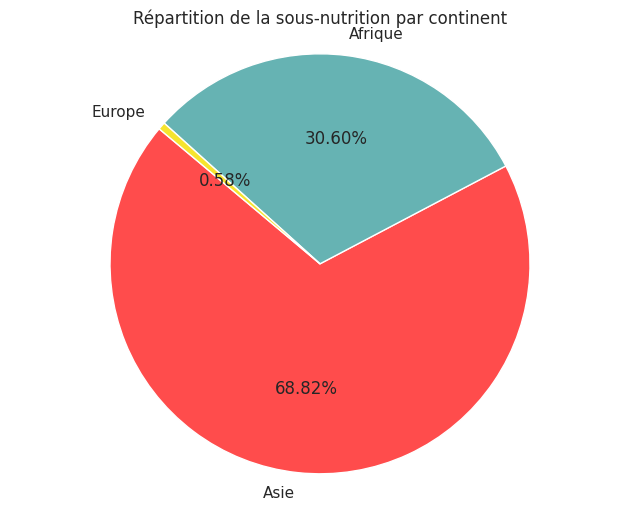

In [374]:
import matplotlib.pyplot as plt

# Agrégation par continent
data = (
    df_jointure_2017
    .groupby('Continent')['sous-nutrition']
    .sum()
)

# Garder uniquement les continents voulus
continents_a_garder = ['Asie', 'Afrique', 'Europe']
data = data.loc[continents_a_garder]

# Calcul des pourcentages (optionnel mais plus clair)
data_pct = data / data.sum() * 100

# Graphique
colors = ['#FF4C4C', '#66B3B3', '#F6E42E']

plt.figure(figsize=(8, 6))
plt.pie(
    data_pct,
    labels=data_pct.index,
    autopct='%1.2f%%',
    startangle=140,
    colors=colors
)

plt.axis('equal')
plt.title('Répartition de la sous-nutrition par continent')
plt.show()

#Relation entre taux de sous-nutrition et disponibilité alimentaire en Kcal -jour-personne

/tmp/ipython-input-3976700737.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,


          pays  dispo_kcal  sous_nutrition_pct   population
0       Zambie      1924.0            0.000000   16853599.0
1   Madagascar      2056.0           43.018302   25570512.0
2  Afghanistan      2087.0           30.581787   36296113.0
3        Haïti      2089.0           49.169733   10982366.0
4        Tchad      2109.0           40.621298   15016753.0
5     Zimbabwe      2113.0            0.000000   14236595.0
6      Ouganda      2126.0            0.000000   41166588.0
7     Éthiopie      2129.0           20.206781  106399924.0
8  Timor-Leste      2129.0           32.173531    1243258.0
9      Namibie      2166.0           16.648402    2402633.0


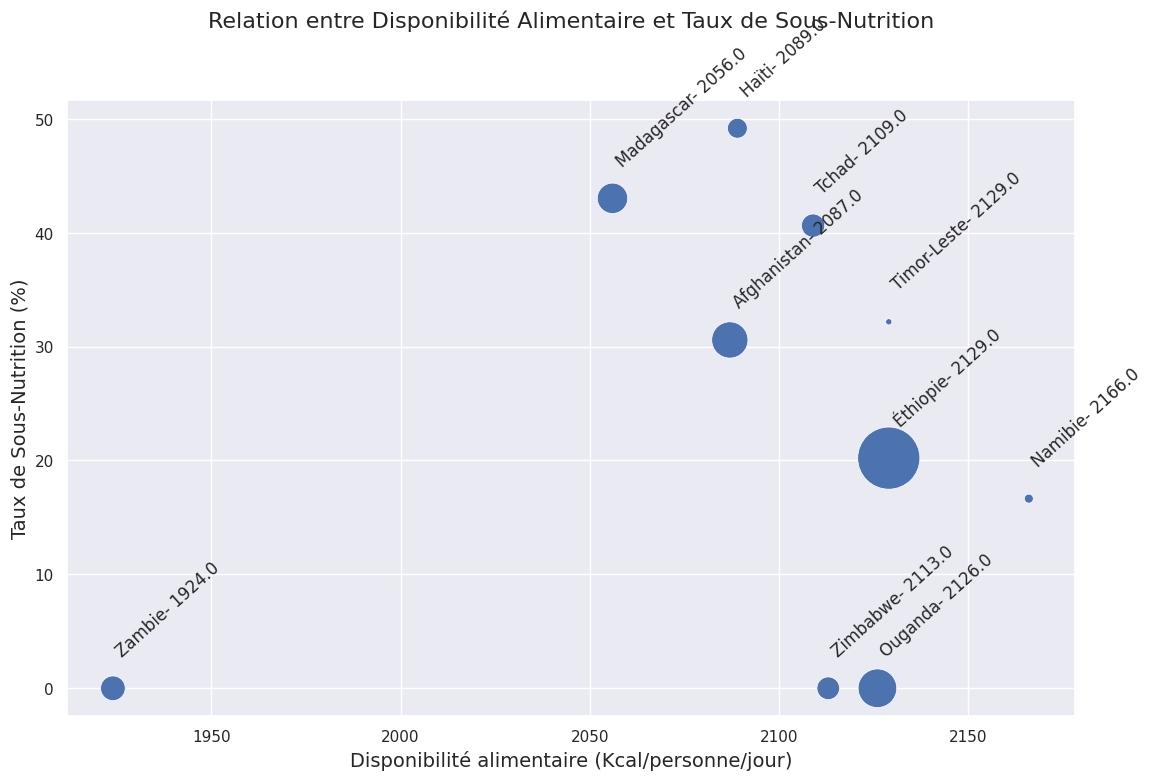

In [375]:
#Relation entre taux de sous-nutrition et disponibilité alimentaire en Kcal/jour/personne
# création d'un dataset fusionné
df_jointureDispoAlimentaire_Popu2017 = pd.merge(df_jointure_2017,jointureDispoAlimentaire_Popu2017, left_on='Zone', right_on='Zone', how='inner')

# Trier par ordre croissant
df_jointureDispoAlimentaire_Popu2017 = df_jointureDispoAlimentaire_Popu2017.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=True)

# Ne garder que les 10 premiers de la liste
top10 = df_jointureDispoAlimentaire_Popu2017.head(10)

# Exemple de données
data = {
    'pays': top10['Zone'].tolist(),   # Top10 pays
    'dispo_kcal': top10['Disponibilité alimentaire (Kcal/personne/jour)'].tolist(),     # Disponibilité alimentaire Kcal
    'sous_nutrition_pct': df_jointureDispoAlimentaire_Popu2017.loc[df_jointureDispoAlimentaire_Popu2017['Zone'].isin(top10['Zone']), 'sous_nutrition_pct'].tolist(),
    'population':top10['population'].tolist()  # Optionnel
}

df = pd.DataFrame(data)

#création d'une palette de couleurs
colors = ['#FF4C4C', '#66B3B3', '#F6E42E', '#8B4513', '#FFA07A', '#98FF98']

# Construire le nuage de points
plt.figure(figsize=(13, 8))
sns.scatterplot(data=df,
                 x="dispo_kcal",
                 y="sous_nutrition_pct",
                 size="population",
                 legend=False,
                 sizes=(20, 2000),
                 palette=colors)

print (df.head(10))
# Ajout des étiquettes de pays avec sous-nutrition
for i in range(df.shape[0]):
    plt.text(
       df["dispo_kcal"][i],
       df["sous_nutrition_pct"][i] + 2.5,  # Ajustez la position verticale
       f"{df['pays'][i]}- {df['dispo_kcal'][i]} ",
       horizontalalignment='left',
       verticalalignment='bottom',
       fontsize=12,
       rotation=42
    )
# Titre et labels
# Ajouter un titre aligné à gauche
plt.title('Relation entre Disponibilité Alimentaire et Taux de Sous-Nutrition', fontsize=16, loc='center', pad=53)

plt.xlabel('Disponibilité alimentaire (Kcal/personne/jour)', fontsize=14)
plt.ylabel('Taux de Sous-Nutrition (%)', fontsize=14)

# Affichage de la grille
plt.grid(True)

# Montrer le graphique
plt.show()

# Répartition des hypothèses de nutrition par continent

     Zone  Année_x  population  Année_y  sous-nutrition  sous_nutrition_pct  \
0  Zambie     2017  16853599.0     2017             0.0                 0.0   
1  Zambie     2017  16853599.0     2017             0.0                 0.0   
2  Zambie     2017  16853599.0     2017             0.0                 0.0   
3  Zambie     2017  16853599.0     2017             0.0                 0.0   
4  Zambie     2017  16853599.0     2017             0.0                 0.0   

  Continent  Disponibilité alimentaire (Kcal/personne/jour)      Année  \
0   Afrique                                          1924.0  2012-2014   
1   Afrique                                          1924.0  2013-2015   
2   Afrique                                          1924.0  2014-2016   
3   Afrique                                          1924.0  2015-2017   
4   Afrique                                          1924.0  2016-2018   

  sous_nutrition  
0            NaN  
1            NaN  
2            NaN  
3   

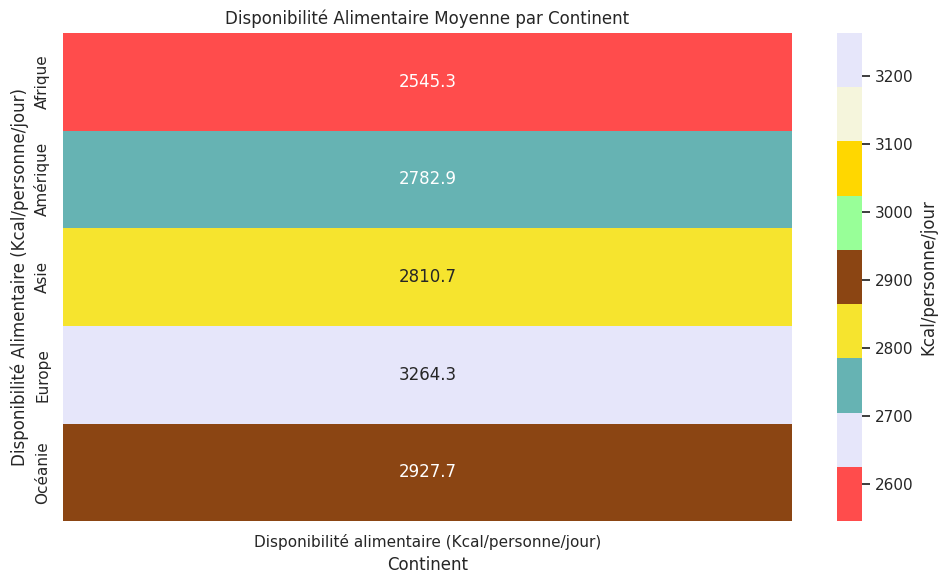

In [376]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fusionner les DataFrames
df_map1_continent = pd.merge(
    df_jointureDispoAlimentaire_Popu2017,
    df_sous_nutrition_2017,
    left_on='Zone',            # Vérifiez que 'Zone' existe dans les deux DataFrames
    right_on='Zone',          # Vérifiez que 'Zone' existe également dans le second DataFrame
    how='inner'
)

# Afficher les 5 premières lignes
print(df_map1_continent.head(5))

# Filtrer par groupby des continents
moyenne_par_continent = df_map1_continent.groupby('Continent')['Disponibilité alimentaire (Kcal/personne/jour)'].mean().reset_index()

# Afficher la liste des continents et leurs moyennes
print(moyenne_par_continent)

# Couleurs pour la heat map
colors1 = ['#FF4C4C', '#E6E6FA','#66B3B3','#F6E42E', '#8B4513','#98FF98','#FFD700','#F5F5DC','#E6E6FA']

# Création d'une heatmap avec la moyenne par continent
plt.figure(figsize=(10, 6))
sns.heatmap(moyenne_par_continent.set_index('Continent'), cmap=colors1, annot=True, fmt='.1f', cbar_kws={'label': 'Kcal/personne/jour'})
plt.title('Disponibilité Alimentaire Moyenne par Continent')
plt.xlabel('Continent')
plt.ylabel('Disponibilité Alimentaire (Kcal/personne/jour)')
plt.tight_layout()  # Ajuste l'affichage
plt.show()

#Répartition des zones qui importent des produits d'origine animale

Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock', 'Continent'],
      dtype='object')
Origine       animale
Continent            
Afrique    71000000.0
Amérique          0.0
Asie              0.0
Europe      1000000.0
Océanie           0.0


/tmp/ipython-input-580493851.py:23: FutureWarning: The provided callable <function sum at 0x7bd0615c9760> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df_map1_continent = dispo_alimentaire.pivot_table(


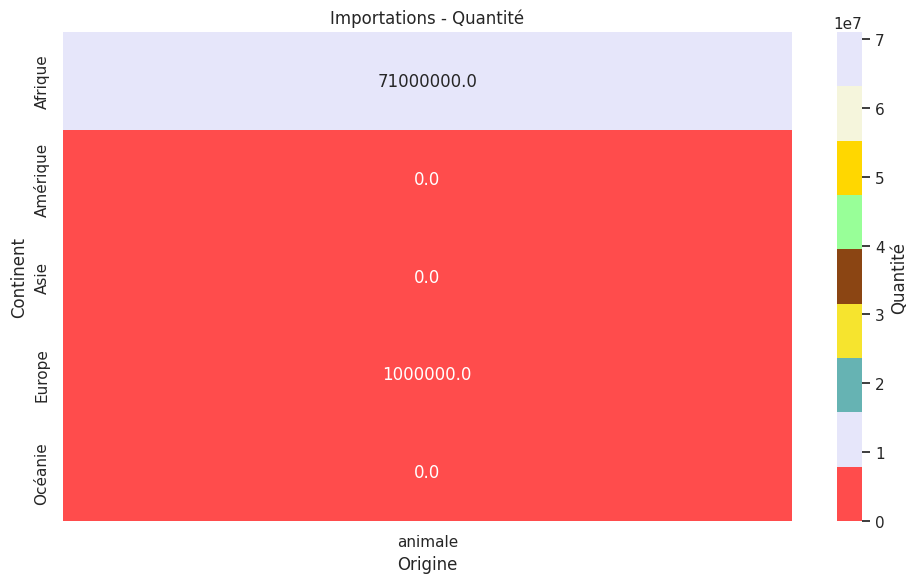

In [377]:
# on cherche les pays importateurs de produits d'origine animale

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# On cherche les pays exportateurs ou importateurs de végétaux
dispo_alimentaire["Continent"] = dispo_alimentaire["Zone"].map(continent_map)

# Supprimez les lignes où la colonne "Continent" est NaN
dispo_alimentaire = dispo_alimentaire.dropna(subset=["Continent"])

# Supprimez les doublons
dispo_alimentaire = dispo_alimentaire.drop_duplicates(subset=['Continent'])


# Vérifiez les noms de colonnes
print(dispo_alimentaire.columns)

# Vérifiez si la colonne existe avant de l'utiliser
if 'Importations - Quantité' in dispo_alimentaire.columns:
    df_map1_continent = dispo_alimentaire.pivot_table(
        index='Continent',
        columns='Origine',
        values='Importations - Quantité',
        aggfunc=np.sum
    )
else:
    print("La colonne 'Importations - Quantité' n'existe pas.")

# Afficher les 5 premières lignes
print(df_map1_continent.head(5))

# Pas besoin de grouper ici, puisque vous avez déjà la somme dans le pivot
# Enlevez la section groupby ici
# moyenne_par_continent = df_map1_continent.groupby('Continent')['Origine'].mean().reset_index()

# Couleurs pour la heat map
colors1 = ['#FF4C4C', '#E6E6FA','#66B3B3','#F6E42E', '#8B4513','#98FF98','#FFD700','#F5F5DC','#E6E6FA']

# Création d'une heatmap avec les données agrégées par continent
plt.figure(figsize=(10, 6))
sns.heatmap(df_map1_continent, cmap=colors1, annot=True, fmt='.1f', cbar_kws={'label': 'Quantité'})
plt.title('Importations - Quantité')
plt.xlabel('Origine')
plt.ylabel('Continent')
plt.tight_layout()  # Ajuste l'affichage
plt.show()

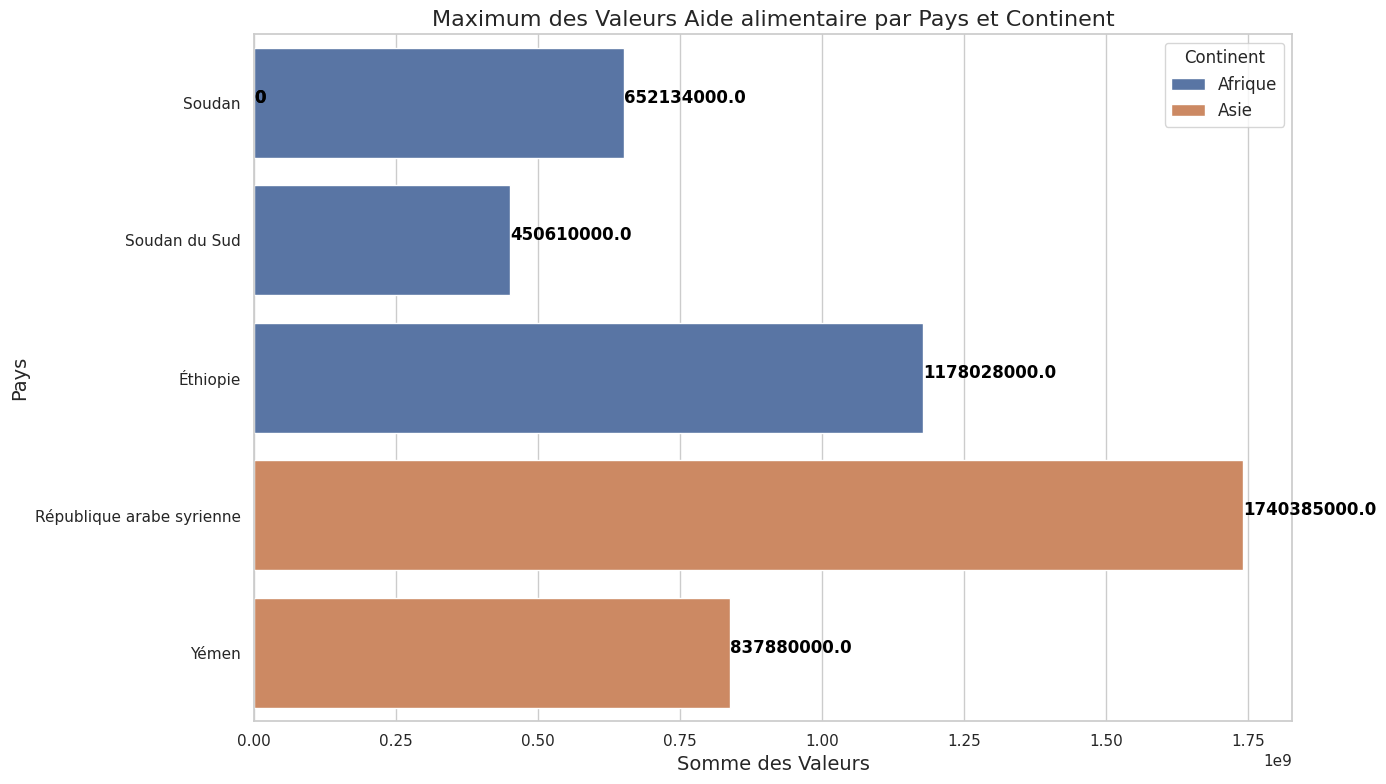

In [378]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Trier les 10 données agrégées par ordre décroissant
pays_max_aide = aide_agregée.sort_values(by='Valeur', ascending=False).head(10)

pays_max_aide["continent"] = pays_max_aide["zone"].map(continent_map)

# Calcul de la somme des valeurs par pays et continent
sums = pays_max_aide.groupby(['continent', 'zone'])['Valeur'].sum().reset_index()

# Configuration de la palette de couleurs
sns.set(style="whitegrid")

# Création du graphique
plt.figure(figsize=(14, 8))
bar_plot = sns.barplot(data=sums, x='Valeur', y='zone', hue='continent', dodge=False)

# Ajout de titres et labels
plt.title('Maximum des Valeurs Aide alimentaire par Pays et Continent', fontsize=16)
plt.xlabel('Somme des Valeurs', fontsize=14)
plt.ylabel('Pays', fontsize=14)
plt.legend(title='Continent', fontsize=12)

# Affichage des valeurs sur les barres
for p in bar_plot.patches:
    bar_plot.annotate(f'{p.get_width()}', (p.get_width(), p.get_y() + p.get_height() / 2),
                      horizontalalignment='left', size=12, color='black', weight='bold')

plt.tight_layout()
plt.show()

#Répartition des zones qui exportent des produits d'origine  végétale

/tmp/ipython-input-3574639461.py:23: FutureWarning: The provided callable <function sum at 0x7bd0615c9760> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  produit_vgetaux = filtre_vgetaux.pivot_table(
/tmp/ipython-input-3574639461.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  produit_vgetaux_filtré['Part'] = round(produit_vgetaux_filtré.sum(axis=1) / produit_vgetaux_filtré.sum().sum() * 100, 2)


Continent                   Afrique  Amérique        Asie      Europe  \
Produit                                                                 
Agrumes, Autres           3000000.0       0.0   2000000.0         0.0   
Alcool, non Comestible  178000000.0       0.0         0.0         0.0   
Aliments pour enfants     5000000.0       0.0         0.0         0.0   
Ananas                   72000000.0       0.0         0.0         0.0   
Arachides Decortiquees   13000000.0       0.0   1000000.0         0.0   
...                             ...       ...         ...         ...   
Sésame                          0.0       0.0  11000000.0         0.0   
Thé                       8000000.0       0.0         0.0         0.0   
Tomates                  65000000.0       0.0         0.0  25000000.0   
Vin                     605000000.0       0.0         0.0         0.0   
Épices, Autres           17000000.0       0.0   5000000.0         0.0   

Continent                   Océanie  Part  
Produi

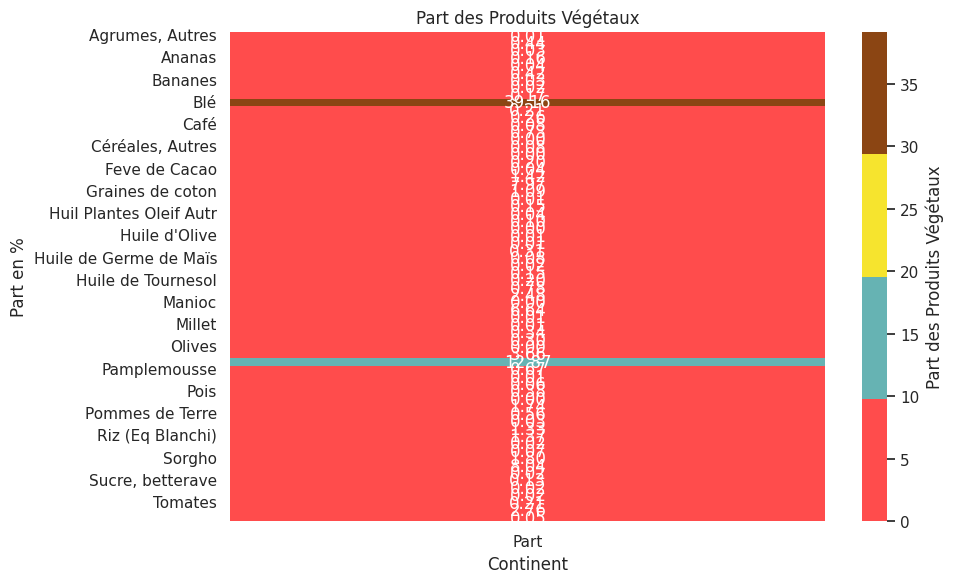

In [379]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le DataFrame
dispo_alimentaire_original = pd.read_csv('dispo_alimentaire.csv')

# Mapper les zones aux continents
dispo_alimentaire_original["Continent"] = dispo_alimentaire_original["Zone"].map(continent_map)

# Supprimer les lignes sans continent
dispo_alimentaire_original = dispo_alimentaire_original.dropna(subset=["Continent"])

# Filtrage pour l'origine végétale et suppression des doublons
filtre_vgetaux = dispo_alimentaire_original[dispo_alimentaire_original['Origine'] == 'vegetale'].drop_duplicates(subset=['Produit', 'Continent'])

# Vérifiez si des données ont été trouvées
if filtre_vgetaux.empty:
    print("Aucune donnée trouvée pour la catégorie spécifiée.")
else:
    # Créer la table pivot
    produit_vgetaux = filtre_vgetaux.pivot_table(
        index='Produit',
        columns='Continent',
        values='Exportations - Quantité',  # S'assurer que cette ligne ait une virgule à la fin
        aggfunc=np.sum
    )

    # Conversion des milliers de tonnes en kg
    produit_vgetaux = produit_vgetaux * 1000000

    # Filtrer pour exclure les produits avec de faibles exportations
    produit_vgetaux_filtré = produit_vgetaux[produit_vgetaux.sum(axis=1) > 1000]  # Ajustez le seuil selon vos besoins

    # Calcul de la part des produits
    produit_vgetaux_filtré['Part'] = round(produit_vgetaux_filtré.sum(axis=1) / produit_vgetaux_filtré.sum().sum() * 100, 2)

    # Affichage des résultats pour vérification
    print(produit_vgetaux_filtré)

    # Couleurs pour la heatmap
    colors1 = ['#FF4C4C', '#66B3B3', '#F6E42E', '#8B4513']

    # Création d'une heatmap pour la part des produits végétaux
    plt.figure(figsize=(10, 6))
    sns.heatmap(produit_vgetaux_filtré[['Part']], cmap=colors1, annot=True, fmt='.2f', cbar_kws={'label': 'Part des Produits Végétaux'})
    plt.title('Part des Produits Végétaux')
    plt.xlabel('Continent')
    plt.ylabel('Part en %')
    plt.tight_layout()  # Ajuste l'affichage
    plt.show()

#Quels continents exportent le plus de végétaux ?

/tmp/ipython-input-2222186661.py:23: FutureWarning: The provided callable <function sum at 0x7bd0615c9760> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  produit_vgetaux = filtre_vgetaux.pivot_table(


Produit    Agrumes, Autres  Alcool, non Comestible  Aliments pour enfants  \
Continent                                                                   
Afrique          3000000.0             178000000.0              5000000.0   
Amérique               0.0                     0.0                    0.0   
Asie             2000000.0                     0.0                    0.0   
Europe                 0.0                     0.0                    0.0   
Océanie                0.0              32000000.0              7000000.0   

Produit        Ananas  Arachides Decortiquees       Avoine    Bananes  \
Continent                                                               
Afrique    72000000.0              13000000.0    4000000.0  8000000.0   
Amérique          0.0                     0.0          0.0        0.0   
Asie              0.0               1000000.0          0.0        0.0   
Europe            0.0                     0.0          0.0        0.0   
Océanie     4000000.0 

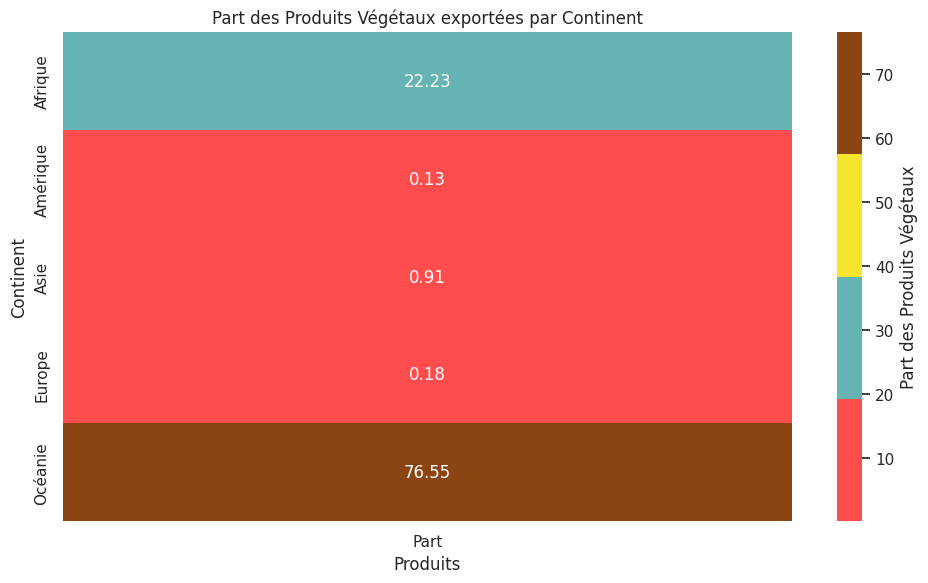

In [380]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le DataFrame
dispo_alimentaire_original = pd.read_csv('dispo_alimentaire.csv')

# Mapper les zones aux continents
dispo_alimentaire_original["Continent"] = dispo_alimentaire_original["Zone"].map(continent_map)

# Supprimer les lignes sans continent
dispo_alimentaire_original = dispo_alimentaire_original.dropna(subset=["Continent"])

# Filtrage pour l'origine végétale et suppression des doublons
filtre_vgetaux = dispo_alimentaire_original[dispo_alimentaire_original['Origine'] == 'vegetale'].drop_duplicates(subset=['Produit', 'Continent'])

# Vérifiez si des données ont été trouvées
if filtre_vgetaux.empty:
    print("Aucune donnée trouvée pour la catégorie spécifiée.")
else:
    # Créer la table pivot avec Continent en index
    produit_vgetaux = filtre_vgetaux.pivot_table(
        index='Continent',
        columns='Produit',
        values='Exportations - Quantité',  # S'assurer que cette ligne ait une virgule à la fin
        aggfunc=np.sum
    )

    # Conversion des milliers de tonnes en kg
    produit_vgetaux = produit_vgetaux * 1000000

    # Filtrer pour exclure les produits avec de faibles exportations
    produit_vgetaux_filtré = produit_vgetaux[produit_vgetaux.sum(axis=1) > 1000]  # Ajustez le seuil selon vos besoins

    # Calcul de la part des produits
    produit_vgetaux_filtré['Part'] = round(produit_vgetaux_filtré.sum(axis=1) / produit_vgetaux_filtré.sum().sum() * 100, 2)

    # Affichage des résultats pour vérification
    print(produit_vgetaux_filtré)

    # Inspecter les exportations totales avant le filtrage
    print("Exportations Totales:\n", produit_vgetaux.sum())

    # Inspecter les données filtrées
    print("Données Filtrées:\n", produit_vgetaux_filtré)

    # Vérifier la somme des exportations pour les produits filtrés
    print("Somme des Exportations Filtrées:\n", produit_vgetaux_filtré.sum())

    # Couleurs pour la heatmap
    colors1 = ['#FF4C4C', '#66B3B3', '#F6E42E', '#8B4513']

    # Création d'une heatmap pour la part des produits végétaux
    plt.figure(figsize=(10, 6))
    sns.heatmap(produit_vgetaux_filtré[['Part']], cmap=colors1, annot=True, fmt='.2f', cbar_kws={'label': 'Part des Produits Végétaux'})
    plt.title('Part des Produits Végétaux exportées par Continent')
    plt.xlabel('Produits')
    plt.ylabel('Continent')
    plt.tight_layout()  # Ajuste l'affichage
    plt.show()

# Test GEOPANDAS

           Name Description                            geometry
0  Moyen-Orient              POINT Z (4432462.01 4122640.486 0)
Index(['Name', 'Description', 'geometry'], dtype='object')


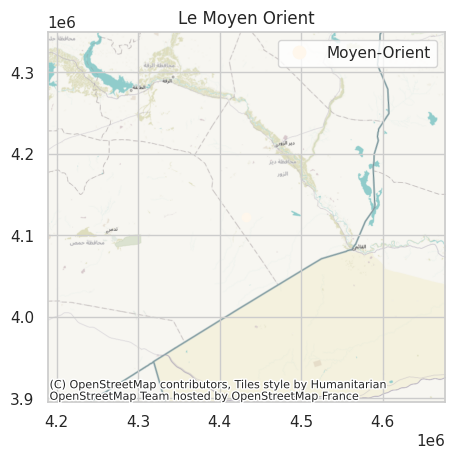

In [381]:
#Test
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from osgeo import ogr
import contextily as ctx
from shapely.wkt import loads

# Fonction pour lire les données KML et les convertir en DataFrame
def read_kml_to_dataframe(kml_file):
    driver = ogr.GetDriverByName('KML')
    dataSource = driver.Open(kml_file, 0)

    if not dataSource:
        raise Exception("Erreur lors de l'ouverture du fichier KML.")

    layer = dataSource.GetLayer()
    features_list = []

    for feature in layer:
        geom = feature.GetGeometryRef()
        attributes = feature.items()
        attributes['geometry'] = geom.ExportToWkt()
        features_list.append(attributes)

    df = pd.DataFrame(features_list)
    return df

# Chemin vers votre fichier KML
kml_file_path = 'P4.kml'

# Lire les données KML et les convertir en DataFrame
df = read_kml_to_dataframe(kml_file_path)

# Convertir les géométries de WKT en forme Shapely
df['geometry'] = df['geometry'].apply(lambda x: loads(x).simplify(0))

# Convertir le DataFrame en GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry')
gdf.crs = "EPSG:4326"  # Système de coordonnées

# Convertir en projection Web Mercator pour le fond de carte
gdf = gdf.to_crs(epsg=3857)

# Afficher les premières lignes et les colonnes pour vérifier
print(gdf.head())
print(gdf.columns)

# Visualiser la carte avec un fond
ax = gdf.plot(column='Name', cmap='OrRd', legend=True)  # Assurez-vous que 'Name' existe
ctx.add_basemap(ax, crs=gdf.crs)

plt.title('Le Moyen Orient')
plt.show()